In [ ]:
import torch
from ultralytics import YOLO
from PIL import Image, ImageDraw, ImageFont
import os
import sys
import glob
from collections import defaultdict
import matplotlib.pyplot as plt
import cv2
import numpy as np

# --- 로컬 Pororo 모듈 경로 설정 ---
# ★★★ predict2에서 검증된 'pororo_easyocr_main' 모듈 경로로 변경 ★★★
PORORO_PATH = os.path.abspath(os.path.join(os.path.dirname('.'), '..', 'pororo_easyocr_main'))
if PORORO_PATH not in sys.path:
    sys.path.append(PORORO_PATH)
    print(f"Added to sys.path: {PORORO_PATH}")

try:
    # ★★★ EasyPororoOcr 클래스를 임포트 ★★★
    from main import EasyPororoOcr
except ImportError:
    print(f"오류: '{PORORO_PATH}' 경로에서 Pororo 모듈을 찾을 수 없습니다.")
    print("customOCR 폴더와 같은 위치에 'pororo_easyocr_main' 폴더가 있는지 확인해주세요.")
    raise

print("\n필요한 모듈을 모두 로드했습니다.")

Added to sys.path: c:\code\pororo_easyocr_main

필요한 모듈을 모두 로드했습니다.


In [2]:
class YOLOv8_OCR_Predictor:
    """YOLOv8로 객체를 탐지하고, 탐지된 영역에서 OCR을 수행하는 예측기"""

    def __init__(self, model_path, font_path=None):
        # --- 1. 모델 및 OCR 엔진 로드 ---
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"YOLO 모델 가중치 파일을 찾을 수 없습니다: {model_path}")
        
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"사용 장치: {self.device.upper()}")

        print("YOLOv8 모델 로딩 중...")
        self.model = YOLO(model_path)
        self.model.to(self.device)
        
        # ★★★ EasyPororoOcr 엔진으로 초기화 ★★★
        print("EasyPororoOcr 엔진 초기화 중...")
        use_gpu = torch.cuda.is_available()
        self.ocr_reader = EasyPororoOcr(gpu=use_gpu)

        # 시각화를 위한 폰트 설정
        try:
            self.font = ImageFont.truetype(font_path or "malgun.ttf", size=15)
        except IOError:
            print("경고: 'malgun.ttf' 폰트를 찾을 수 없습니다. 기본 폰트를 사용합니다.")
            self.font = ImageFont.load_default()

    def detect_only(self, image_path, conf_threshold=0.5):
        """[1단계] 이미지에서 객체만 탐지합니다 (OCR 없음)."""
        if not os.path.exists(image_path):
            print(f"오류: 이미지 파일을 찾을 수 없습니다: {image_path}")
            return None, None

        original_image = Image.open(image_path).convert("RGB")
        results = self.model.predict(original_image, conf=conf_threshold, verbose=False)
        
        detected_objects = []
        for res in results:
            boxes = res.boxes.cpu().numpy()
            for box in boxes:
                class_id = int(box.cls[0])
                label = self.model.names[class_id]
                confidence = float(box.conf[0])
                coords = [int(c) for c in box.xyxy[0]]
                
                detected_objects.append({'label': label, 'box': coords, 'confidence': confidence})
        
        detected_objects.sort(key=lambda obj: (obj['box'][1], obj['box'][0]))
        return detected_objects, original_image

    def run_ocr_on_detections(self, original_image, detected_objects):
        """
        [2단계] 탐지된 객체 리스트에 대해 OCR을 수행합니다.
        ★★★ 패딩 추가 및 2단계 처리(자르기->OCR)로 정확도/구조 개선 ★★★
        """
        # --- 1. 준비 단계: 모든 탐지 영역을 패딩을 주어 미리 잘라내기 ---
        cropped_pil_images = []
        img_width, img_height = original_image.size
        padding = 8  # 8픽셀 패딩

        for obj in detected_objects:
            box = obj['box']
            # 패딩을 적용하되, 이미지 경계를 넘어가지 않도록 처리
            x1 = max(0, box[0] - padding)
            y1 = max(0, box[1] - padding)
            x2 = min(img_width, box[2] + padding)
            y2 = min(img_height, box[3] + padding)
            
            cropped_pil_images.append(original_image.crop((x1, y1, x2, y2)))

        # --- 2. 처리 단계: 잘라낸 이미지 리스트를 순회하며 OCR 수행 ---
        structured_results = []
        for i, cropped_pil_image in enumerate(cropped_pil_images):
            # predict2에서 검증된 이미지 전처리 수행
            cv_image = np.array(cropped_pil_image)
            cv_image_bgr = cv2.cvtColor(cv_image, cv2.COLOR_RGB2BGR)
            final_image_for_ocr = cv_image_bgr.copy()

            # 잘라낸 이미지에 대해서만 OCR 수행
            self.ocr_reader.run_ocr(final_image_for_ocr, debug=False)
            ocr_result = self.ocr_reader.get_ocr_result()
            
            text_list = [item[1] for item in ocr_result] if ocr_result else []
            final_text = ' '.join(text_list)

            # 원본 탐지 정보와 OCR 결과를 결합
            original_obj = detected_objects[i]
            structured_results.append({
                'label': original_obj['label'], 
                'text': final_text.strip(),
                'box': original_obj['box'], 
                'confidence': f"{original_obj['confidence']:.2f}"
            })
            
        return structured_results

    def draw_detections(self, image, detections):
        """탐지 결과(박스 + 라벨)만 시각화합니다."""
        draw = ImageDraw.Draw(image)
        label_colors = {
            "DATE_HEADER": "#ff7f0e", "DATE": "#1f77b4", "TIME": "#d62728",
            "MERCHANT": "#2ca02c", "MEMO": "#9467bd", "AMOUNT_IN": "#8c564b",
            "AMOUNT_OUT": "#e377c2", "BALANCE": "#7f7f7f",
        }
        for det in detections:
            box, label, confidence = det['box'], det['label'], det['confidence']
            color = label_colors.get(label, "#bcbd22")
            draw.rectangle(box, outline=color, width=3)
            label_text = f"{label} ({confidence:.2f})"
            text_bbox = draw.textbbox((box[0], box[1]), label_text, font=self.font)
            label_bg_box = [box[0], box[1] - (text_bbox[3] - text_bbox[1]) - 6, box[0] + (text_bbox[2] - text_bbox[0]) + 8, box[1]]
            draw.rectangle(label_bg_box, fill=color)
            draw.text((box[0] + 4, box[1] - (text_bbox[3] - text_bbox[1]) - 4), label_text, fill="white", font=self.font)
        return image

    def draw_predictions(self, image, predictions):
        """최종 예측 결과(박스 + 라벨 + OCR 텍스트)를 시각화합니다."""
        draw = ImageDraw.Draw(image)
        label_colors = {
            "DATE_HEADER": "#ff7f0e", "DATE": "#1f77b4", "TIME": "#d62728",
            "MERCHANT": "#2ca02c", "MEMO": "#9467bd", "AMOUNT_IN": "#8c564b",
            "AMOUNT_OUT": "#e377c2", "BALANCE": "#707070FF",
        }
        for pred in predictions:
            box, label, text, confidence = pred['box'], pred['label'], pred['text'], pred['confidence']
            color = label_colors.get(label, "#bcbd22")
            draw.rectangle(box, outline=color, width=3)
            label_text = f"{label}: {text} ({confidence})"
            text_bbox = draw.textbbox((box[0], box[1]), label_text, font=self.font)
            label_bg_box = [box[0], box[1] - (text_bbox[3] - text_bbox[1]) - 6, box[0] + (text_bbox[2] - text_bbox[0]) + 8, box[1]]
            draw.rectangle(label_bg_box, fill=color)
            draw.text((box[0] + 4, box[1] - (text_bbox[3] - text_bbox[1]) - 4), label_text, fill="white", font=self.font)
        return image

print("YOLOv8_OCR_Predictor 클래스가 탐지/OCR 분리 기능으로 업데이트되었습니다.")

YOLOv8_OCR_Predictor 클래스가 탐지/OCR 분리 기능으로 업데이트되었습니다.


In [3]:
# --- 1. 설정 ---
# 학습된 YOLO 모델 가중치 파일 경로
MODEL_PATH = 'C:/code/customOCR/bank_statement_detector/yolov8l_e50_bs8_0727_continued/weights/best.pt'
# 테스트할 이미지가 있는 디렉토리
TEST_IMAGE_DIR = '../bank_statement_test'
TEST_IMAGE_DIR2 = '../bank_statement'
# 예측 결과 이미지를 저장할 디렉토리
OUTPUT_DIR = 'C:/code/customOCR/yolo_predictions'
# 객체 탐지를 위한 신뢰도 임계값
CONF_THRESHOLD = 0.01
# 사용할 폰트 경로 (None으로 두면 시스템 기본 폰트 또는 'malgun.ttf' 시도)
FONT_PATH = None 

# --- 2. 예측기 초기화 ---
try:
    predictor = YOLOv8_OCR_Predictor(model_path=MODEL_PATH, font_path=FONT_PATH)
except Exception as e:
    print(f"예측기 초기화 실패: {e}")
    # Stop execution if predictor fails
    raise

사용 장치: CUDA
YOLOv8 모델 로딩 중...
EasyPororoOcr 엔진 초기화 중...


In [4]:
# --- 1단계: YOLO 영역 탐지 결과 확인 ---
test_image_files = glob.glob(os.path.join(TEST_IMAGE_DIR, '*.png')) + \
                   glob.glob(os.path.join(TEST_IMAGE_DIR, '*.jpg')) + \
                   glob.glob(os.path.join(TEST_IMAGE_DIR2, '*.png')) + \
                   glob.glob(os.path.join(TEST_IMAGE_DIR2, '*.jpg'))

if not test_image_files:
    print(f"오류: '{TEST_IMAGE_DIR}' 또는 '{TEST_IMAGE_DIR2}' 폴더에서 테스트 이미지를 찾을 수 없습니다.")
else:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"탐지 결과 이미지를 '{OUTPUT_DIR}' 폴더에 저장합니다.")

    for image_path in test_image_files:
        detections, image = predictor.detect_only(image_path, conf_threshold=CONF_THRESHOLD)
        if detections is None:
            continue

        result_image = predictor.draw_detections(image.copy(), detections)
        
        # ★★★ 변경: 노트북에 출력하는 대신 파일로 저장 ★★★
        output_filename = "detection_" + os.path.basename(image_path)
        output_path = os.path.join(OUTPUT_DIR, output_filename)
        result_image.save(output_path)
        print(f"{os.path.basename(image_path)} -> 탐지 결과 저장 완료: {output_path}")

탐지 결과 이미지를 'C:/code/customOCR/yolo_predictions' 폴더에 저장합니다.
sc1.png -> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_sc1.png
sanup1.jpg -> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_sanup1.jpg
sanup2.jpg -> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_sanup2.jpg
sanup3.jpg -> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_sanup3.jpg
sanup4.jpg -> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_sanup4.jpg
kookmin1.png -> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_kookmin1.png
kookmin2.png -> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_kookmin2.png
kookmin3.png -> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_kookmin3.png
kookmin4.png -> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_kookmin4.png
shinhan1.png -> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_shinhan1.png
shinhyup.png -> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_shinhyup.png
toss1.png 


최종 OCR 결과 이미지를 'C:/code/customOCR/yolo_predictions' 폴더에 저장하고 화면에 출력합니다.

--- [2단계: OCR+결과] sc1.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_sc1.png


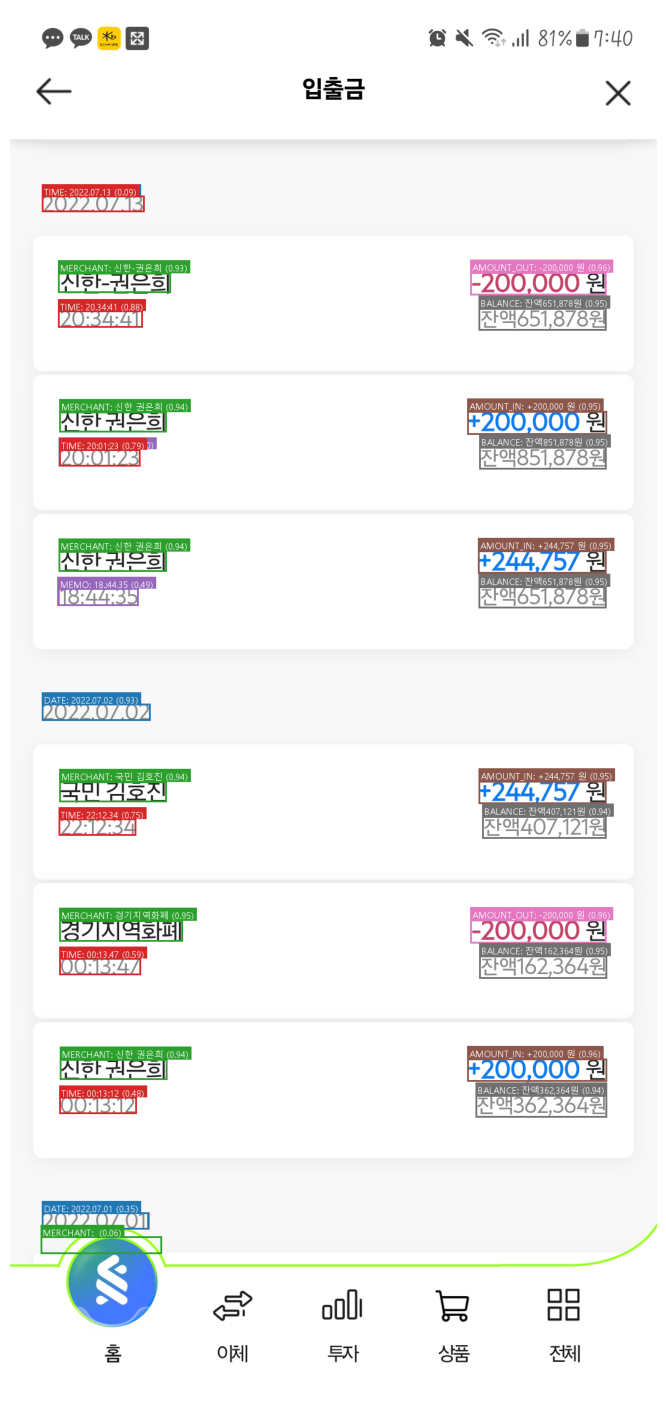

[텍스트 요약]
- AMOUNT_IN: +200,000 원, +244,757 원, +244,757 원, +200,000 원
- AMOUNT_OUT: -200,000 원, -200,000 원
- BALANCE: 잔액651,878원, 잔액851,878원, 잔액651,878원, 잔액407,121원, 잔액162,364원, 잔액362,364원
- DATE: 2022.07.13, 2022.07.02, 2022,07.01
- MEMO: 20:.01:23, 18.:44.35
- MERCHANT: 신한-권은희, 신한 권은희, 신한 권은희, 국민 김호진, 경기지역화폐, 신한 권은희, 
- TIME: 2022.07.13, 20.34:41, 20:01:23, 18:44:35, 22:12.34, 00:13.47, 00:13:12, 2022,07.01
--------------------------------------------------

--- [2단계: OCR+결과] sanup1.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_sanup1.jpg


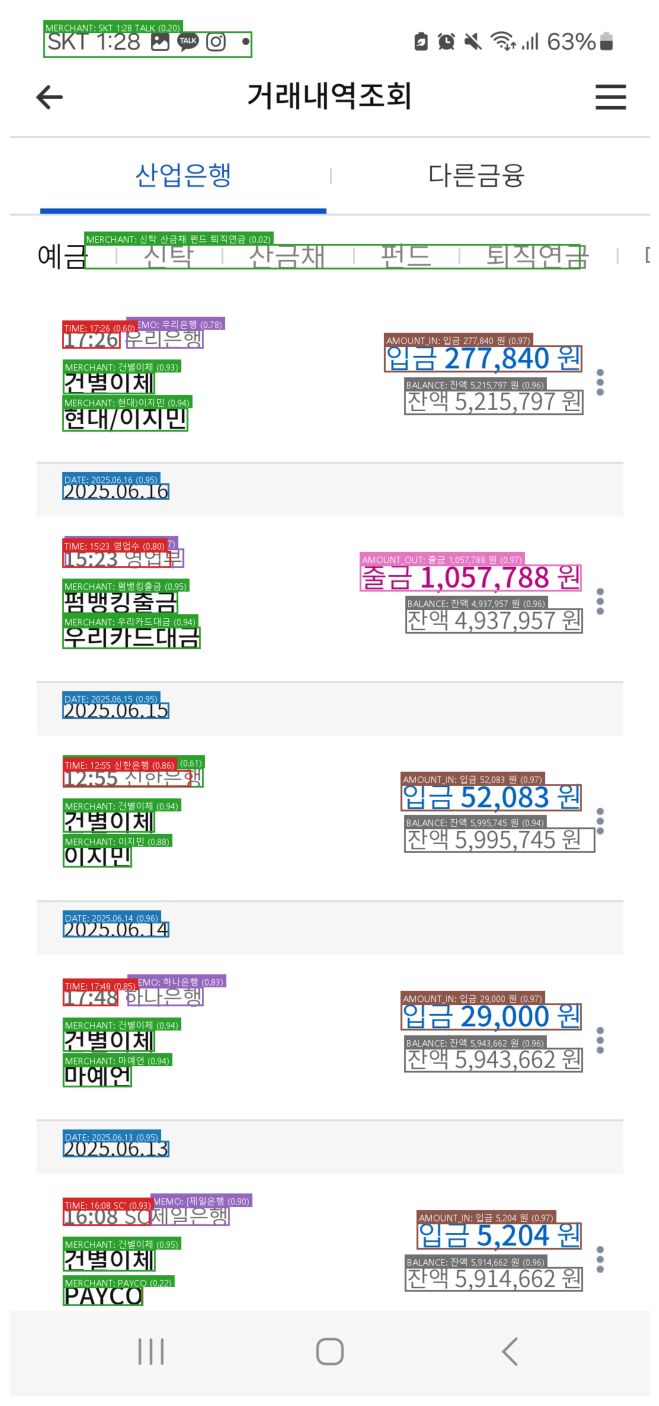

[텍스트 요약]
- AMOUNT_IN: 입금 277,840 원, 입금 52,083 원, 입금 29,000 원, 입금 5,204 원
- AMOUNT_OUT: 출금 1,057,788 원
- BALANCE: 잔액 5,215,797 원, 잔액 4,937,957 원, 잔액 5,995,745 원, 잔액 5,943,662 원, 잔액 5,914,662 원
- DATE: 2025.06.16, 2025.06.15, 2025.06.14, 2025.06.13
- MEMO: 우리은행, 15:23 영업부, 하나은행, [제일은행
- MERCHANT: SKT 1:28 TALK, 신탁 산금채 펀드 퇴직연금, 건별이체, 현대)이지민, 펌뱅킹출금, 우리카드대금, 12:55 신한은행, 건별이체, 이지민, 건별이체, 마예언, 건별이체, PAYCO
- TIME: 17:26, 15:23 영업수, 12:55 신한은행, 17:48, 16:08 SC', PAYCO
--------------------------------------------------

--- [2단계: OCR+결과] sanup2.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_sanup2.jpg


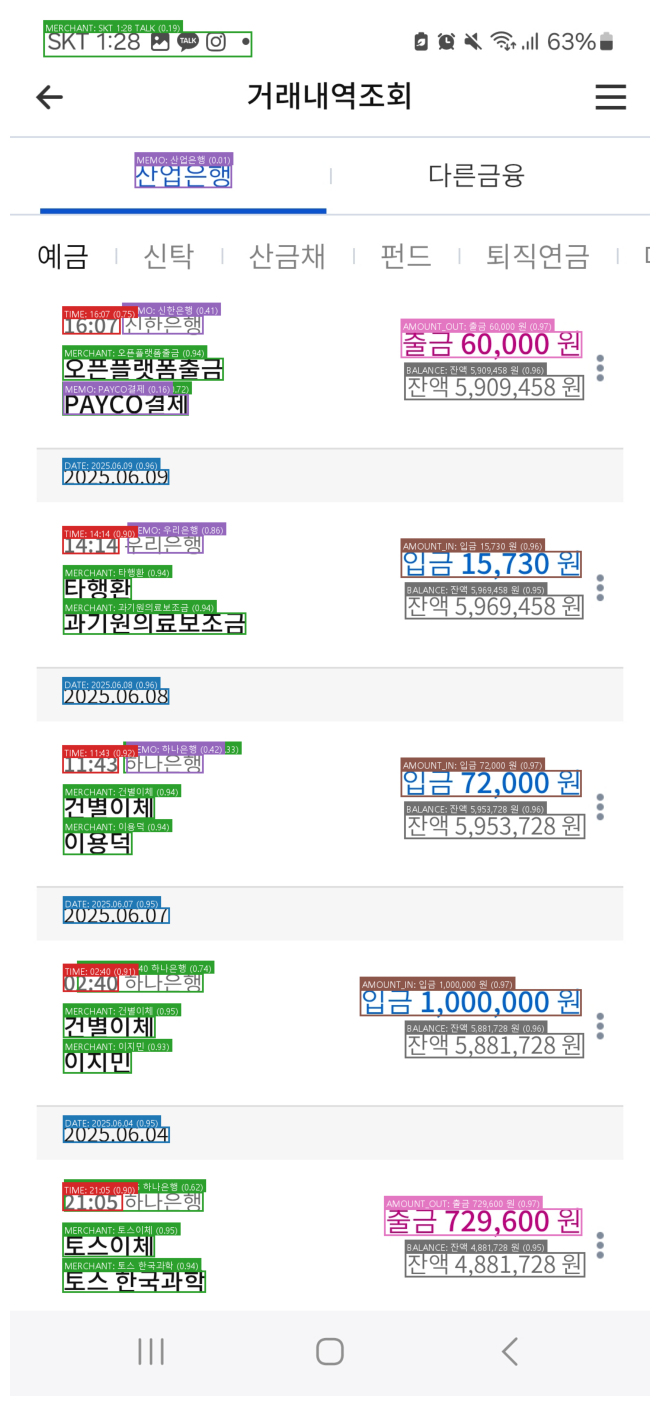

[텍스트 요약]
- AMOUNT_IN: 입금 15,730 원, 입금 72,000 원, 입금 1,000,000 원
- AMOUNT_OUT: 출금 60,000 원, 출금 729,600 원
- BALANCE: 잔액 5,909,458 원, 잔액 5,969,458 원, 잔액 5,953,728 원, 잔액 5,881,728 원, 잔액 4,881,728 원
- DATE: 2025.06.09, 2025.06.08, 2025.06.07, 2025.06.04
- MEMO: 산업은행, 신한은행, PAYCO결제, 우리은행, 하나은행
- MERCHANT: SKT 1:28 TALK, 오픈플랫폼출금, PAYCO결제, 타행환, 과기원의료보조금, 하나은행, 건별이체, 이용덕, 2:40 하나은행, 건별이체, 이지민, 21:05 하나은행, 토스이체, 토스 한국과학
- TIME: 16:07, 14:14, 11:43, 02:40, 21:05
--------------------------------------------------

--- [2단계: OCR+결과] sanup3.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_sanup3.jpg


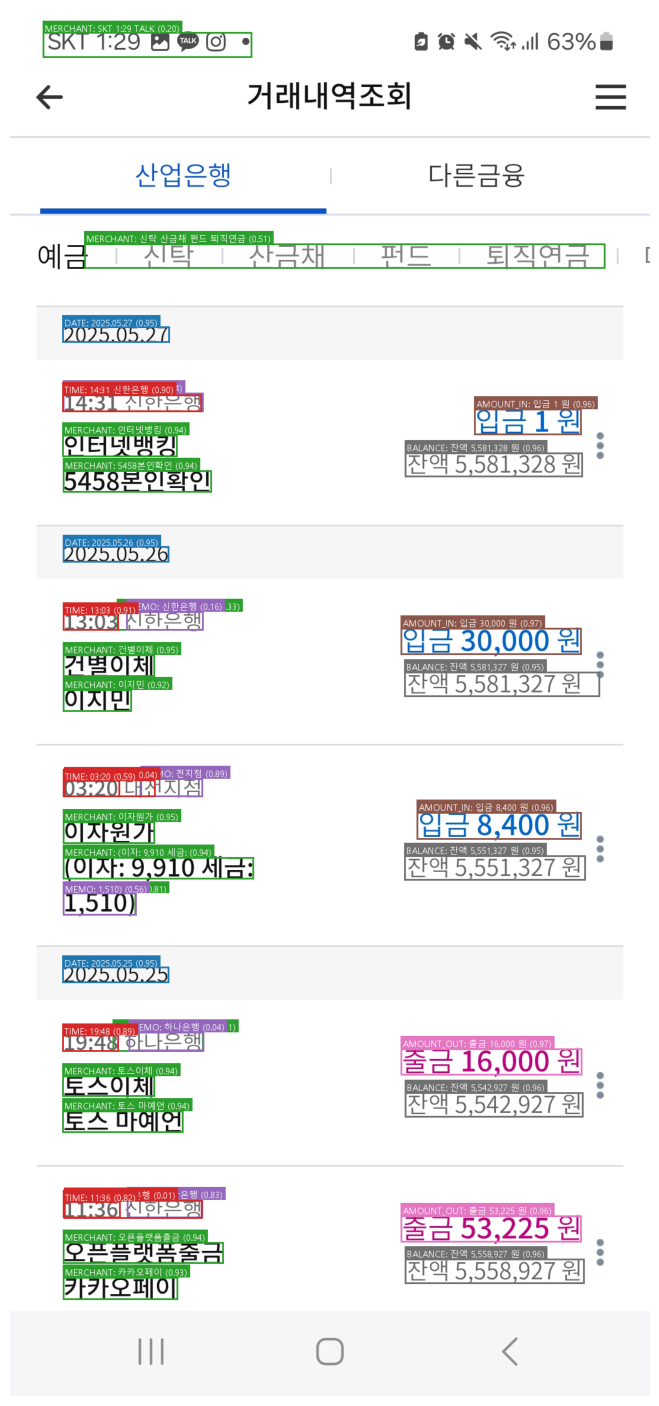

[텍스트 요약]
- AMOUNT_IN: 입금 1 원, 입금 30,000 원, 입금 8,400 원
- AMOUNT_OUT: 출금 16,000 원, 출금 53,225 원
- BALANCE: 잔액 5,581,328 원, 잔액 5,581,327 원, 잔액 5,551,327 원, 잔액 5,542,927 원, 잔액 5,558,927 원
- DATE: 2025.05.27, 2025.05.26, 2025.05.25
- MEMO: 14:31 신한은행, 신한은행, 전지점, 1,510), 하나은행, 신한은행
- MERCHANT: SKT 1:29 TALK, 신탁 산금채 펀드 퇴직연금, 인터넷뱅킹, 5458본인확인, 3 신한은행, 건별이체, 이지민, 이자원가, (이자: 9,910 세금:, 1,510), 8 하나은행, 토스이체, 토스 마예언, 오픈플랫폼출금, 카카오페이
- TIME: 14:31 신한은행, 13:03, 03:20 대전, 03:20, 19:48, 11:36 신한은행, 11:36
--------------------------------------------------

--- [2단계: OCR+결과] sanup4.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_sanup4.jpg


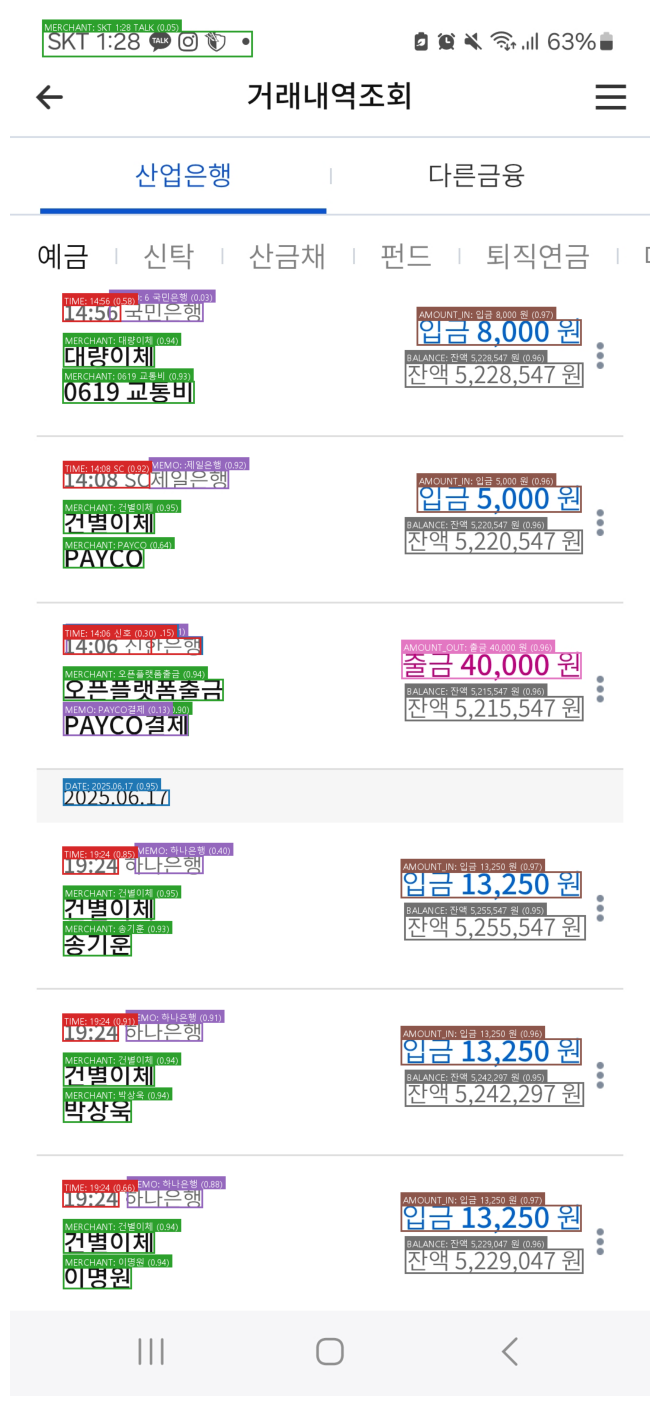

[텍스트 요약]
- AMOUNT_IN: 입금 8,000 원, 입금 5,000 원, 입금 13,250 원, 입금 13,250 원, 입금 13,250 원
- AMOUNT_OUT: 출금 40,000 원
- BALANCE: 잔액 5,228,547 원, 잔액 5,220,547 원, 잔액 5,215,547 원, 잔액 5,255,547 원, 잔액 5,242,297 원, 잔액 5,229,047 원
- DATE: 14:06 신한은행, 2025.06.17
- MEMO: 6 국민은행, :제일은행, 14:06 신한은행, PAYCO결제, 하나은행, 하나은행, 하나은행
- MERCHANT: SKT 1:28 TALK, 대량이체, 0619 교통비, 건별이체, PAYCO, 오픈플랫폼출금, PAYCO결제, 건별이체, 송기훈, 건별이체, 박상욱, 건별이체, 이명원
- TIME: 14:56, 14:08 SC, 14:06 신한은행, 14:06 신호, 19:24, 19:24, 19:24
--------------------------------------------------

--- [2단계: OCR+결과] kookmin1.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_kookmin1.png


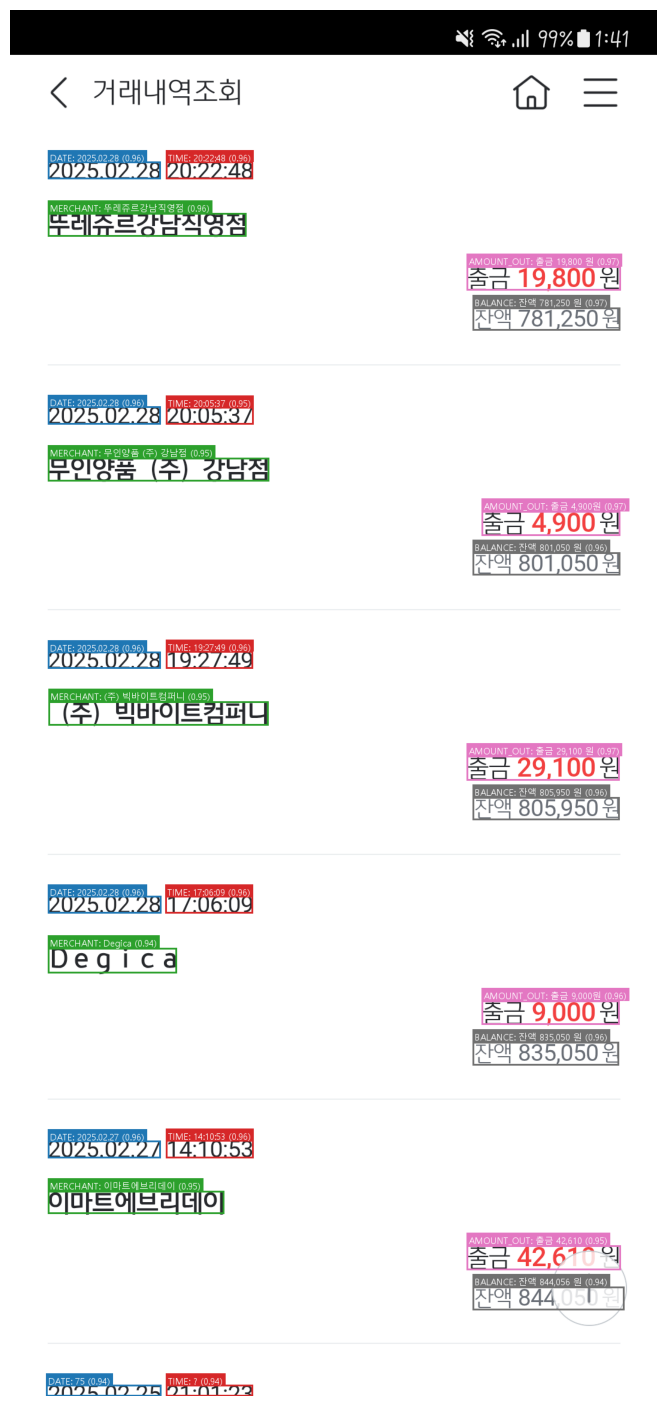

[텍스트 요약]
- AMOUNT_OUT: 출금 19,800 원, 출금 4,900원, 출금 29,100 원, 출금 9,000원, 출금 42,610
- BALANCE: 잔액 781,250 원, 잔액 801,050 원, 잔액 805,950 원, 잔액 835,050 원, 잔액 844,056 원
- DATE: 2025.02.28, 2025.02.28, 2025.02.28, 2025.02.28, 2025.02.27, 75
- MERCHANT: 뚜레쥬르강남직영점, 무인양품 (주) 강남점, (주) 빅바이트컴퍼니, Degica, 이마트에브리데이
- TIME: 20:22:48, 20:05:37, 19:27:49, 17:06:09, 14:10:53, ?
--------------------------------------------------

--- [2단계: OCR+결과] kookmin2.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_kookmin2.png


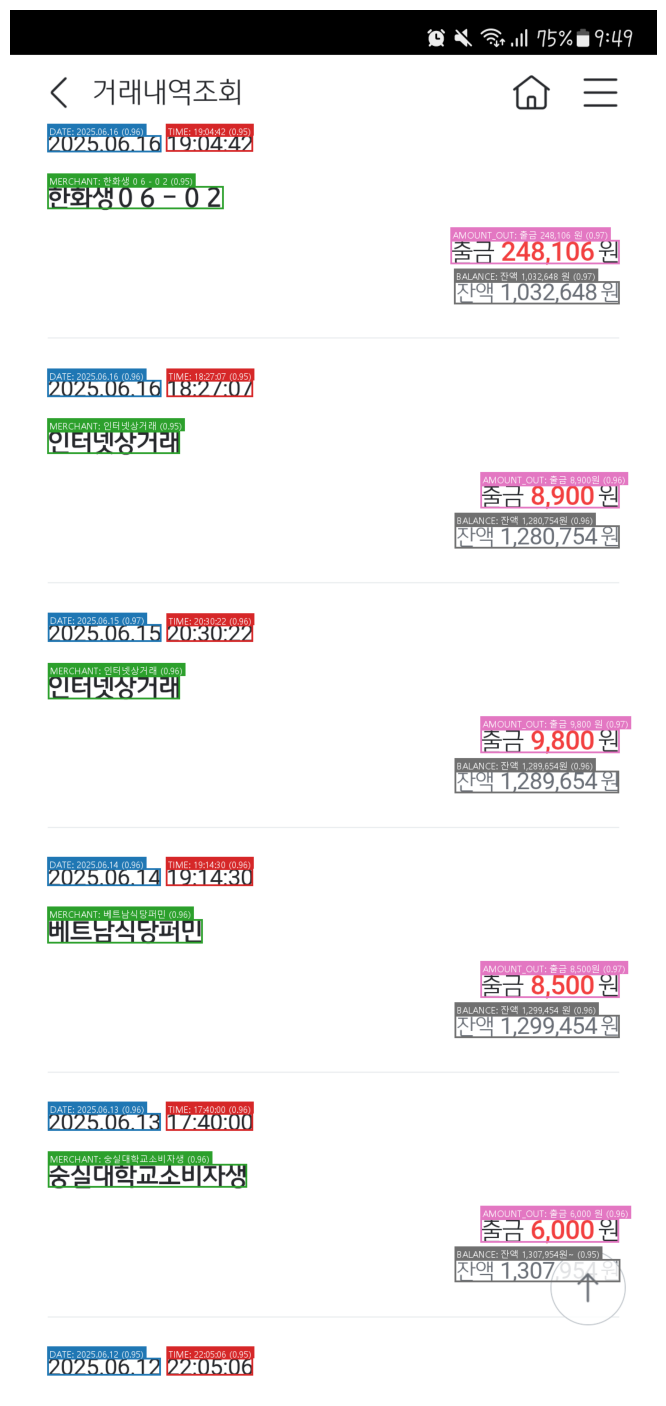

[텍스트 요약]
- AMOUNT_OUT: 출금 248,106 원, 출금 8,900원, 출금 9,800 원, 출금 8,500원, 출금 6,000 원
- BALANCE: 잔액 1,032,648 원, 잔액 1,280,754원, 잔액 1,289,654원, 잔액 1,299,454 원, 잔액 1,307,954원~
- DATE: 2025.06.16, 2025.06.16, 2025.06.15, 2025.06.14, 2025.06.13, 2025.06.12
- MERCHANT: 한화생 0 6 - 0 2, 인터넷상거래, 인터넷상거래, 베트남식당퍼민, 숭실대학교소비자생
- TIME: 19:04:42, 18:27:07, 20:30:22, 19:14:30, 17:40:00, 22:05:06
--------------------------------------------------

--- [2단계: OCR+결과] kookmin3.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_kookmin3.png


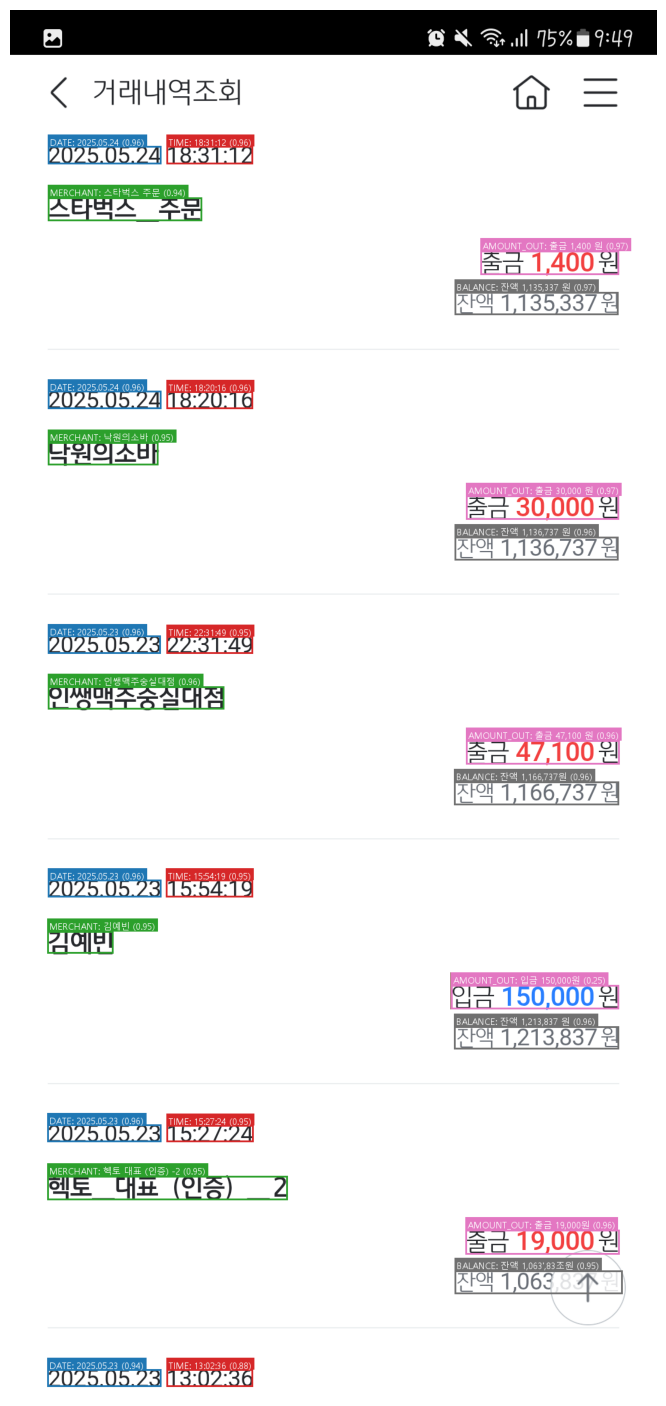

[텍스트 요약]
- AMOUNT_IN: 입금 150,000 원
- AMOUNT_OUT: 출금 1,400 원, 출금 30,000 원, 출금 47,100 원, 입금 150,000원, 출금 19,000원
- BALANCE: 잔액 1,135,337 원, 잔액 1,136,737 원, 잔액 1,166,737원, 잔액 1,213,837 원, 잔액 1,063',83조원
- DATE: 2025.05.24, 2025.05.24, 2025.05.23, 2025.05.23, 2025.05.23, 2025.05.23
- MERCHANT: 스타벅스 주문, 낙원의소바, 인쌩맥주숭실대점, 김예빈, 헥토 대표 (인증) -2
- TIME: 18:31:12, 18:20:16, 22:31:49, 15:54:19, 15:27:24, 13:02:36
--------------------------------------------------

--- [2단계: OCR+결과] kookmin4.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_kookmin4.png


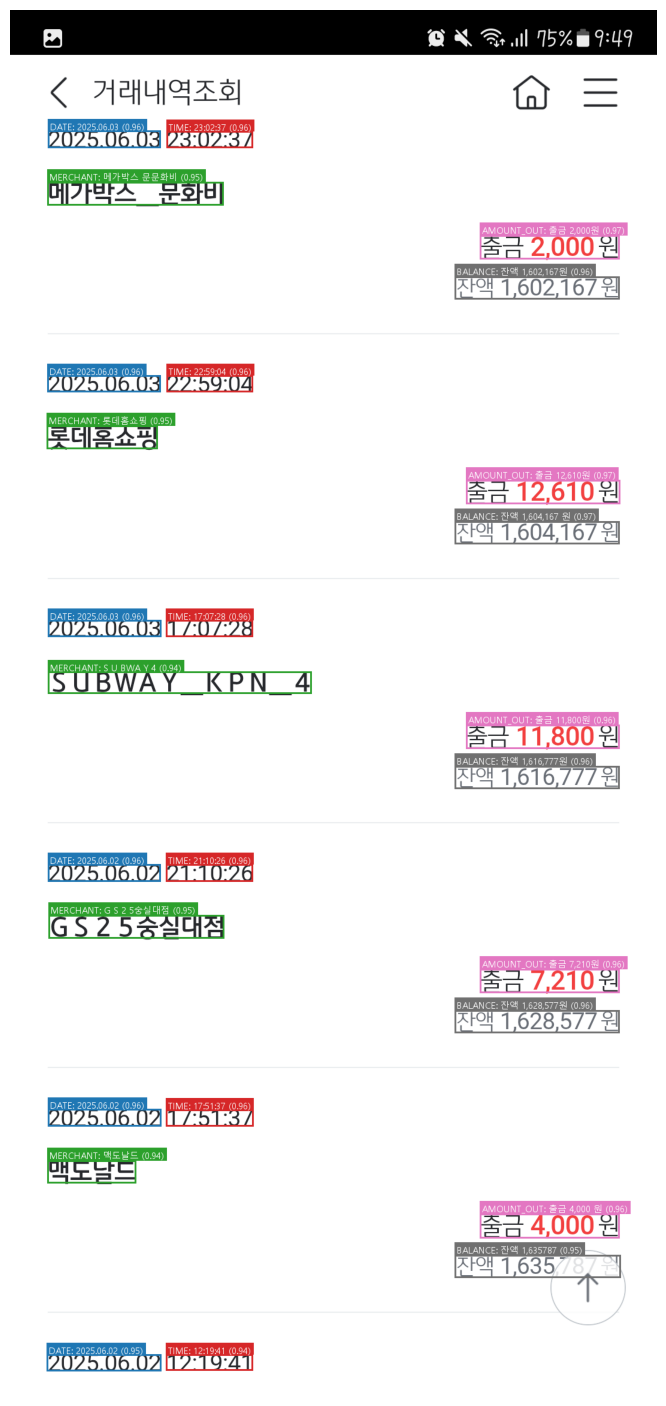

[텍스트 요약]
- AMOUNT_OUT: 출금 2,000원, 출금 12,610원, 출금 11,800원, 출금 7,210원, 출금 4,000 원
- BALANCE: 잔액 1,602,167원, 잔액 1,604,167 원, 잔액 1,616,777원, 잔액 1,628,577원, 잔액 1,635787
- DATE: 2025.06.03, 2025.06.03, 2025.06.03, 2025.06.02, 2025.06.02, 2025.06.02
- MERCHANT: 메가박스 문문화비, 롯데홈쇼핑, S U BWA Y 4, G S 2 5숭실대점, 맥도날드
- TIME: 23:02:37, 22:59:04, 17:07:28, 21:10:26, 17:51:37, 12:19:41
--------------------------------------------------

--- [2단계: OCR+결과] shinhan1.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_shinhan1.png


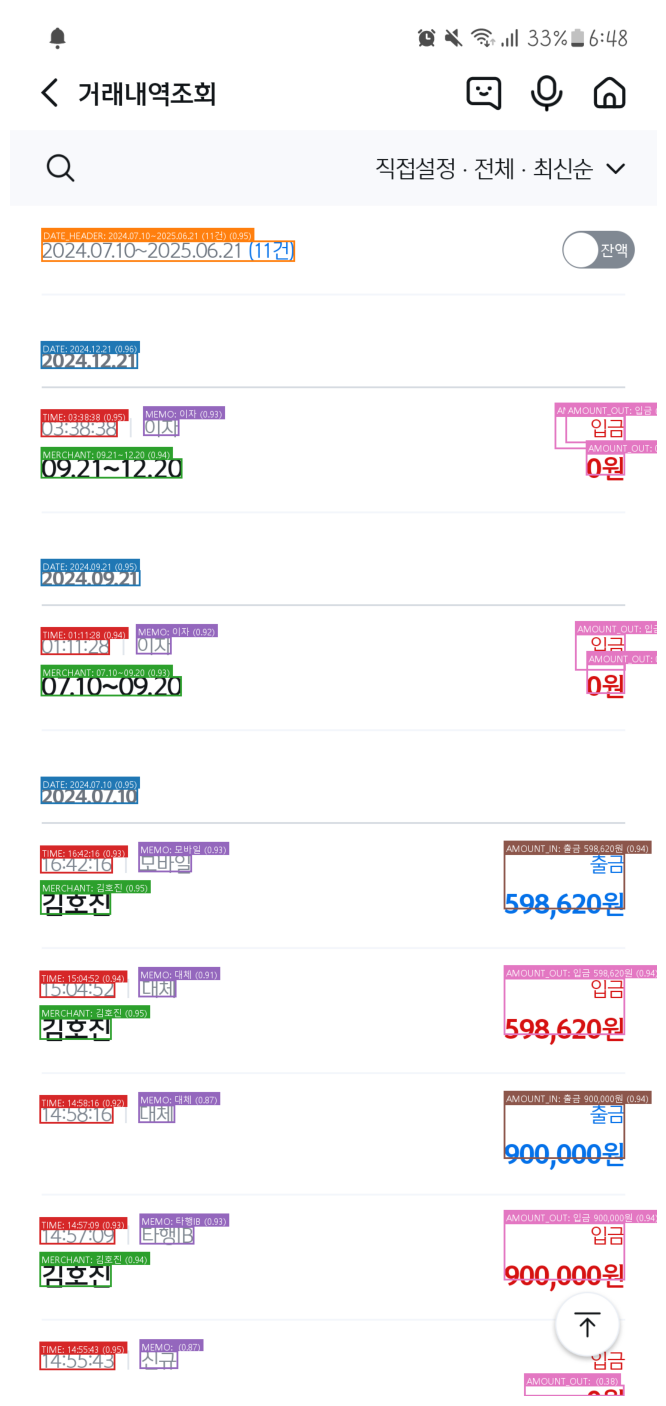

[텍스트 요약]
- AMOUNT_IN: 출금 598,620원, 출금 900,000원
- AMOUNT_OUT: 입금, 입금, 0원, 입금, 0원, 입금 598,620원, 입금 900,000원, 
- DATE: 2024.12.21, 2024.09.21, 2024.07.10
- DATE_HEADER: 2024.07.10~2025.06.21 (11건)
- MEMO: 이자, 이자, 모바일, 대체, 대체, 타행IB, 
- MERCHANT: 09.21~12.20, 07.10~09.20, 김호진, 김호진, 김호진
- TIME: 03:38:38, 01:11:28, 16:42:16, 15:04:52, 14:58:16, 14:57:09, 14:55:43
--------------------------------------------------

--- [2단계: OCR+결과] shinhyup.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_shinhyup.png


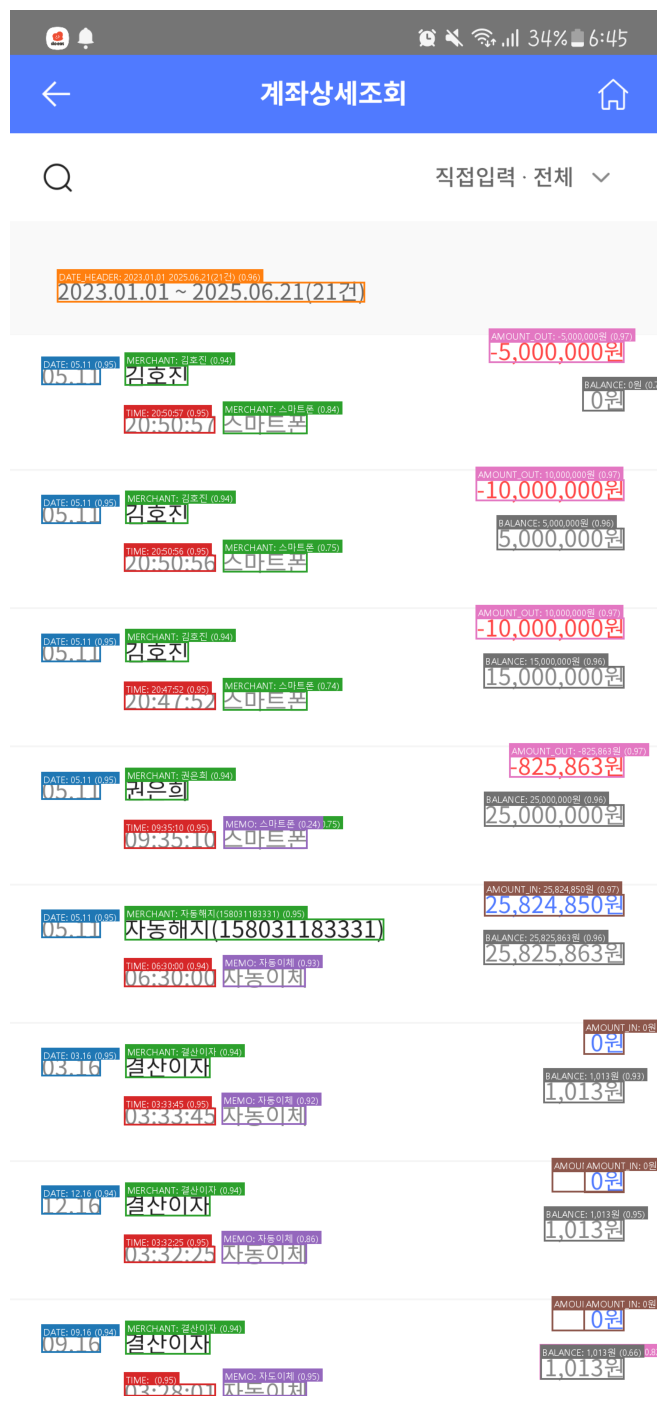

[텍스트 요약]
- AMOUNT_IN: 25,824,850원, 0원, 0원, 0원, 0원, 0원
- AMOUNT_OUT: -5,000,000원, 10,000,000원, 10,000,000원, -825,863원, 1,013원
- BALANCE: 0원, 5,000,000원, 15,000,000원, 25,000,000원, 25,825,863원, 1,013원, 1,013원, 1,013원
- DATE: 05.11, 05.11, 05.11, 05.11, 05.11, 03.16, 12.16, 09.16
- DATE_HEADER: 2023.01.01 2025.06.21(21건)
- MEMO: 스마트폰, 자동이체, 자동이체, 자동이체, 자도이체
- MERCHANT: 김호진, 스마트폰, 김호진, 스마트폰, 김호진, 스마트폰, 권은희, 스마트폰, 자동해지(158031183331), 결산이자, 결산이자, 결산이자
- TIME: 20:50:57, 20:50:56, 20:47:52, 09:35:10, 06:30:00, 03:33:45, 03:32:25, 
--------------------------------------------------

--- [2단계: OCR+결과] toss1.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_toss1.png


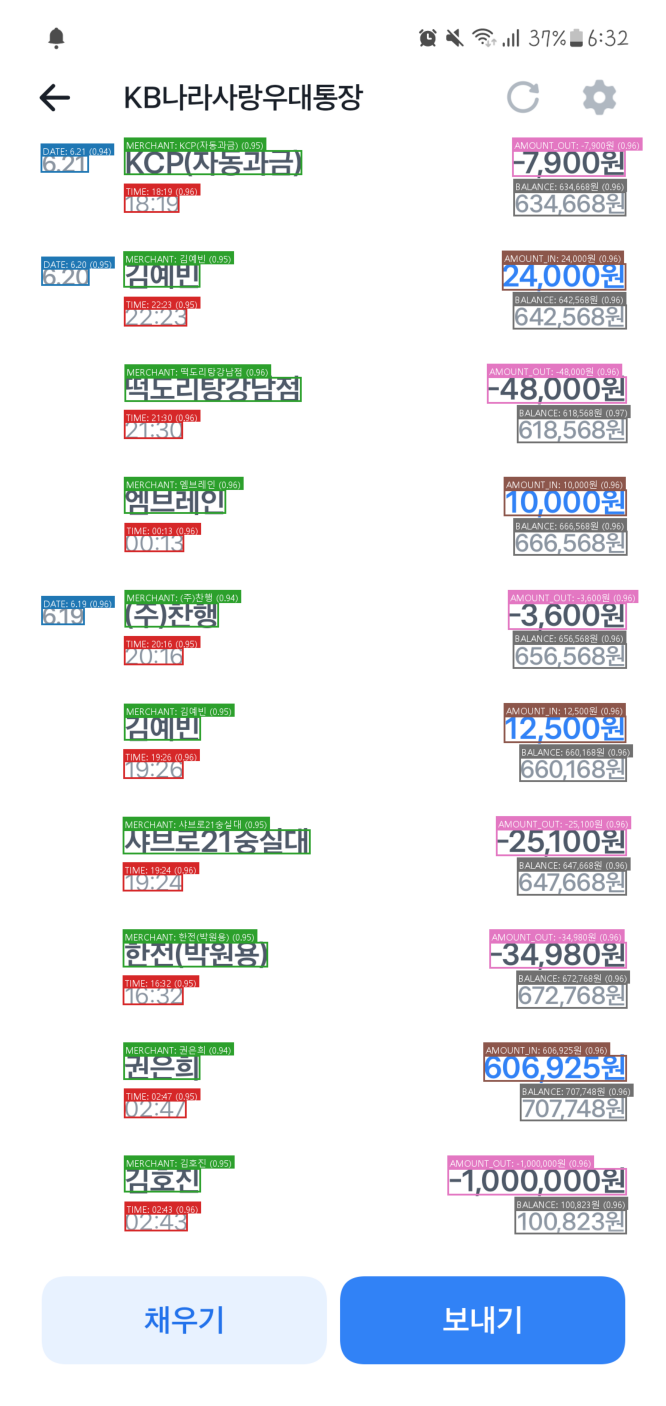

[텍스트 요약]
- AMOUNT_IN: 24,000원, 10,000원, 12,500원, 606,925원
- AMOUNT_OUT: -7,900원, -48,000원, -3,600원, -25,100원, -34,980원, -1,000,000원
- BALANCE: 634,668원, 642,568원, 618,568원, 666,568원, 656,568원, 660,168원, 647,668원, 672,768원, 707,748원, 100,823원
- DATE: 6.21, 6.20, 6.19
- MERCHANT: KCP(자동과금), 김예빈, 떡도리탕강남점, 엠브레인, (주)찬행, 김예빈, 샤브로21숭실대, 한전(박원용), 권은희, 김호진
- TIME: 18:19, 22:23, 21:30, 00:13, 20:16, 19:26, 19:24, 16:32, 02:47, 02:43
--------------------------------------------------

--- [2단계: OCR+결과] toss2.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_toss2.png


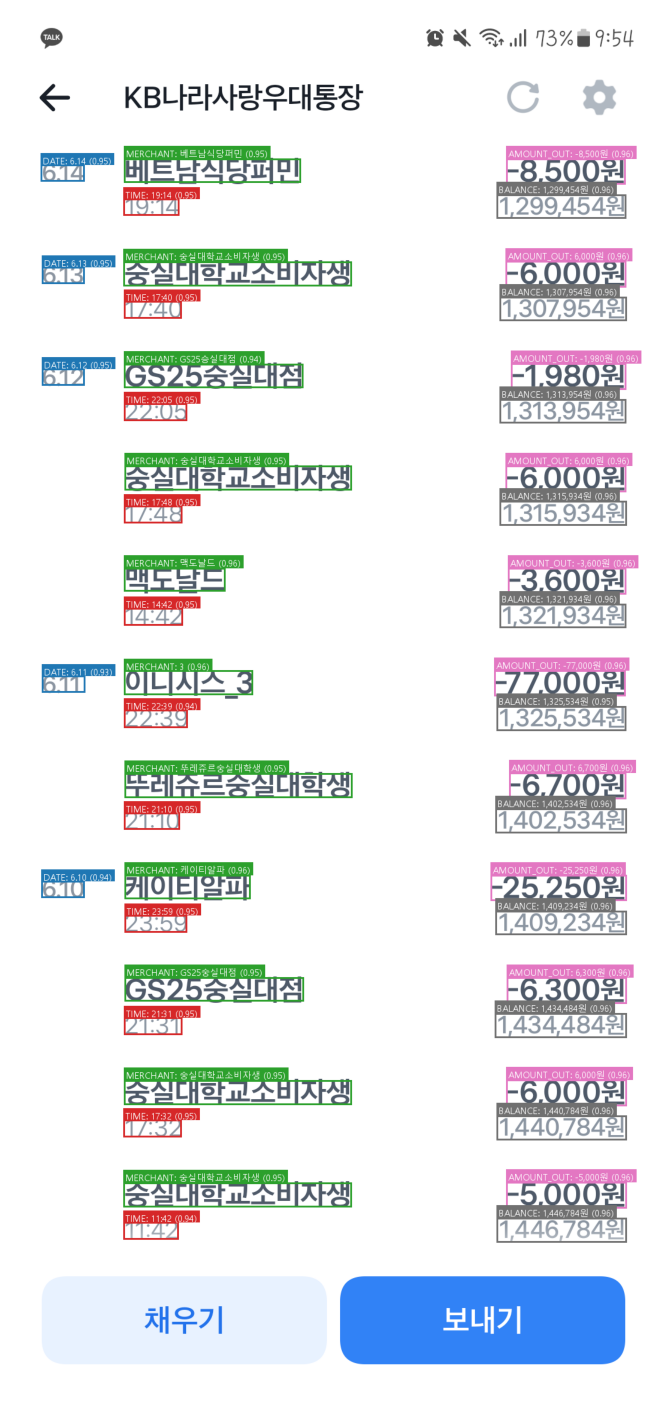

[텍스트 요약]
- AMOUNT_OUT: -8,500원, 6,000원, -1,980원, 6,000원, -3,600원, -77,000원, 6,700원, -25,250원, 6,300원, 6,000원, -5,000원
- BALANCE: 1,299,454원, 1,307,954원, 1,313,954원, 1,315,934원, 1,321,934원, 1,325,534원, 1,402,534원, 1,409,234원, 1,434,484원, 1,440,784원, 1,446,784원
- DATE: 6.14, 6.13, 6.12, 6.11, 6.10
- MERCHANT: 베트남식당퍼민, 숭실대학교소비자생, GS25승실대점, 숭실대학교소비자생, 맥도날드, 3, 뚜레쥬르숭실대학생, 케이티알파, GS25숭실대점, 숭실대학교소비자생, 숭실대학교소비자생
- TIME: 19:14, 17:40, 22:05, 17:48, 14:42, 22:39, 21:10, 23:59, 21:31, 17:32, 11:42
--------------------------------------------------

--- [2단계: OCR+결과] toss3.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_toss3.png


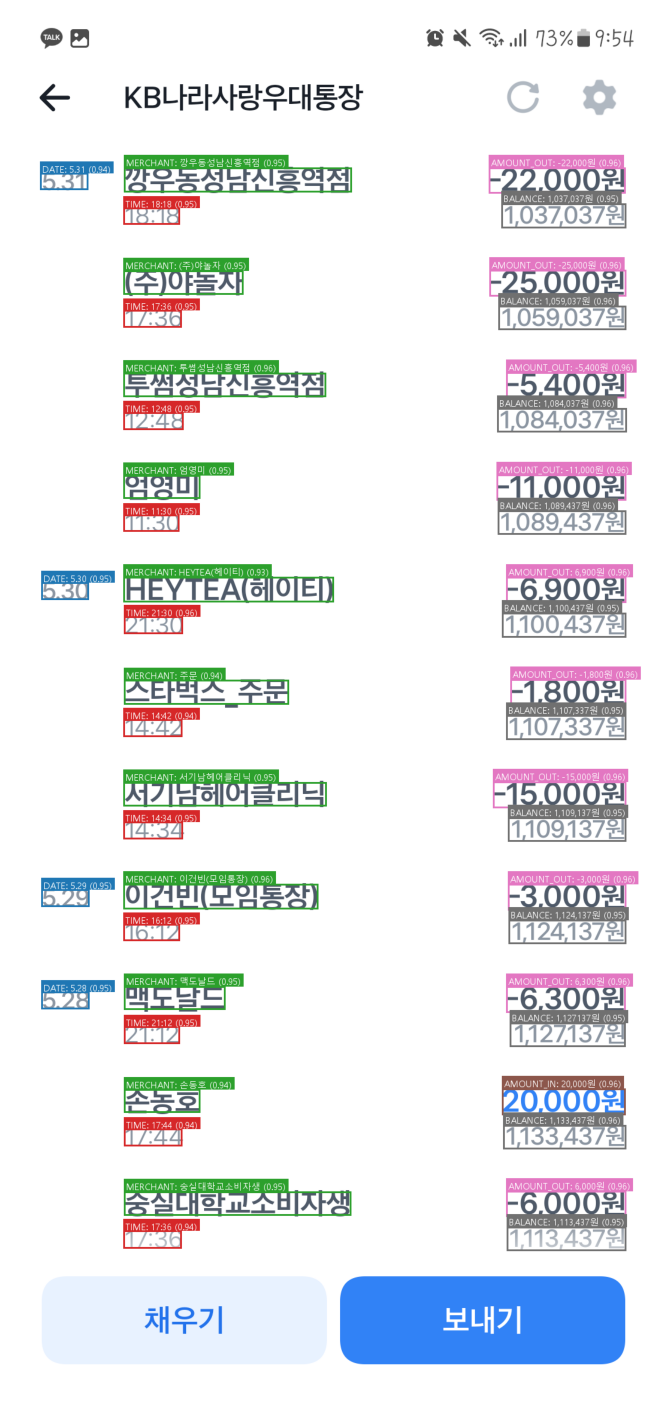

[텍스트 요약]
- AMOUNT_IN: 20,000원
- AMOUNT_OUT: -22,000원, -25,000원, -5,400원, -11,000원, 6,900원, -1,800원, -15,000원, -3,000원, 6,300원, 6,000원
- BALANCE: 1,037,037원, 1,059,037원, 1,084,037원, 1,089,437원, 1,100,437원, 1,107,337원, 1,109,137원, 1,124,137원, 1,127137원, 1,133,437원, 1,113,437원
- DATE: 5.31, 5.30, 5.29, 5.28
- MERCHANT: 깡우동성남신흥역점, (주)야놀자, 투썸성남신흥역점, 엄영미, HEYTEA(헤이티), 주문, 서기남헤어클리닉, 이건빈(모임통장), 맥도날드, 손동호, 숭실대학교소비자생
- TIME: 18:18, 17:36, 12:48, 11:30, 21:30, 14:42, 14:34, 16:12, 21:12, 17:44, 17:36
--------------------------------------------------

--- [2단계: OCR+결과] toss4.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_toss4.png


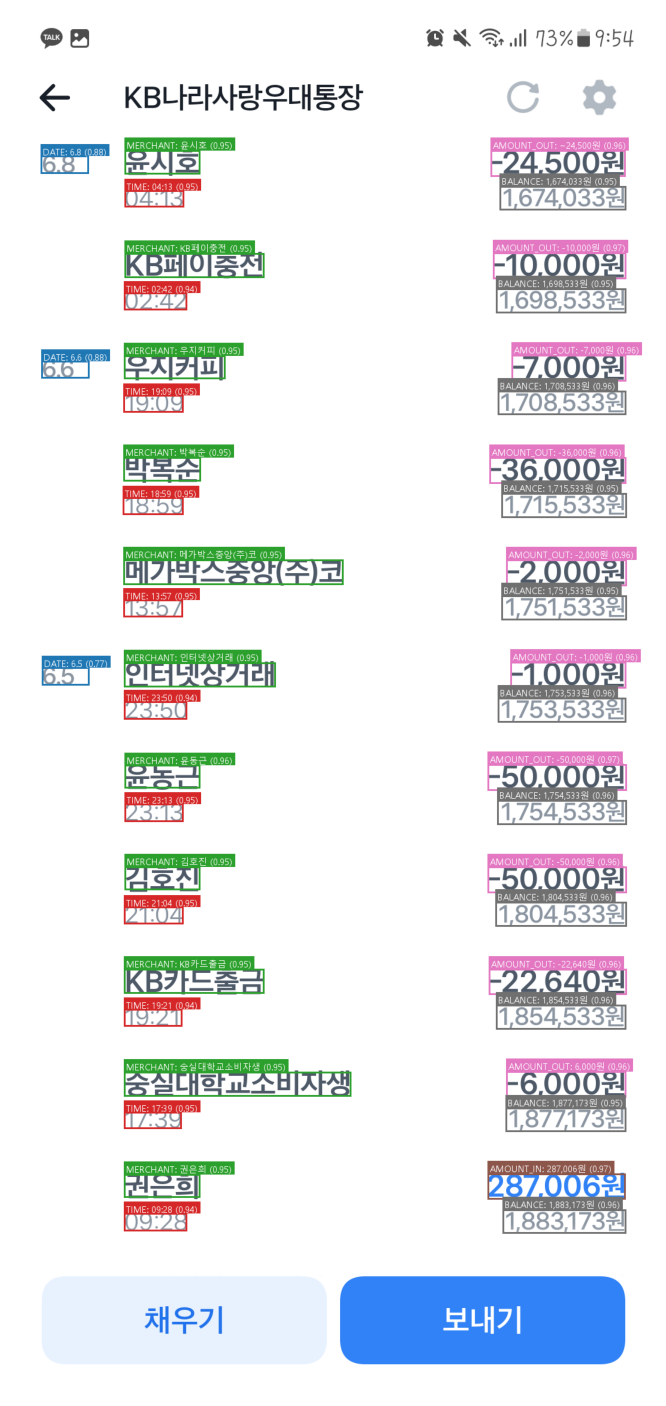

[텍스트 요약]
- AMOUNT_IN: 287,006원
- AMOUNT_OUT: ~24,500원, -10,000원, -7,000원, -36,000원, -2,000원, -1,000원, -50,000원, -50,000원, -22,640원, 6,000원
- BALANCE: 1,674,033원, 1,698,533원, 1,708,533원, 1,715,533원, 1,751,533원, 1,753,533원, 1,754,533원, 1,804,533원, 1,854,533원, 1,877,173원, 1,883,173원
- DATE: 6.8, 6.6, 6.5
- MERCHANT: 윤시호, KB페이충전, 우지커피, 박복순, 메가박스중앙(주)코, 인터넷상거래, 윤동근, 김호진, KB카드출금, 숭실대학교소비자생, 권은희
- TIME: 04:13, 02:42, 19:09, 18:59, 13:57, 23:50, 23:13, 21:04, 19:21, 17:39, 09:28
--------------------------------------------------

--- [2단계: OCR+결과] woori1.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_woori1.png


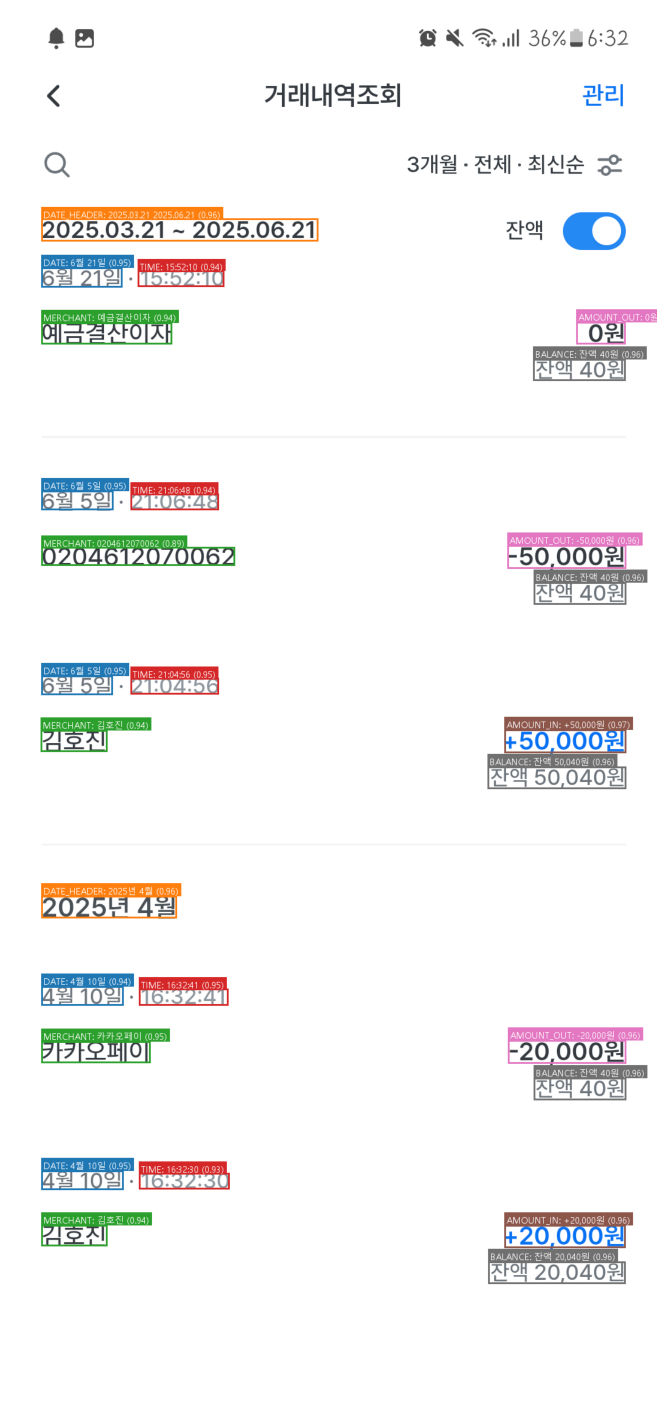

[텍스트 요약]
- AMOUNT_IN: +50,000원, +20,000원
- AMOUNT_OUT: 0원, -50,000원, -20,000원
- BALANCE: 잔액 40원, 잔액 40원, 잔액 50,040원, 잔액 40원, 잔액 20,040원
- DATE: 6월 21일, 6월 5일, 6월 5일, 4월 10일, 4월 10일
- DATE_HEADER: 2025.03.21 2025.06.21, 2025년 4월
- MERCHANT: 예금결산이자, 0204612070062, 김호진, 카카오페이, 김호진
- TIME: 15:52:10, 21:06:48, 21:04:56, 16:32:41, 16:32:30
--------------------------------------------------

--- [2단계: OCR+결과] woori2.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_woori2.png


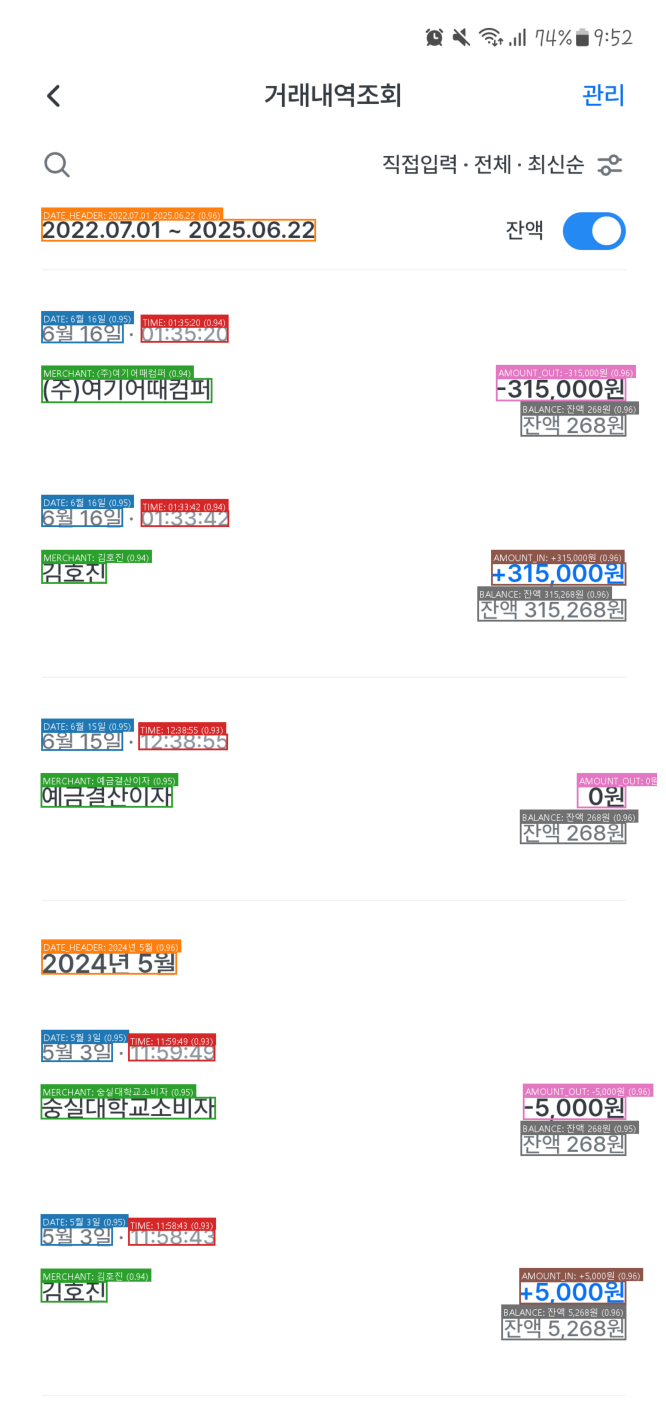

[텍스트 요약]
- AMOUNT_IN: +315,000원, +5,000원
- AMOUNT_OUT: -315,000원, 0원, -5,000원
- BALANCE: 잔액 268원, 잔액 315,268원, 잔액 268원, 잔액 268원, 잔액 5,268원
- DATE: 6월 16일, 6월 16일, 6월 15일, 5월 3일, 5월 3일
- DATE_HEADER: 2022.07.01 2025.06.22, 2024년 5월
- MERCHANT: (주)여기어때컴퍼, 김호진, 예금결산이자, 숭실대학교소비자, 김호진
- TIME: 01:35:20, 01:33:42, 12:38:55, 11:59:49, 11:58:43
--------------------------------------------------

--- [2단계: OCR+결과] woori3.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_woori3.png


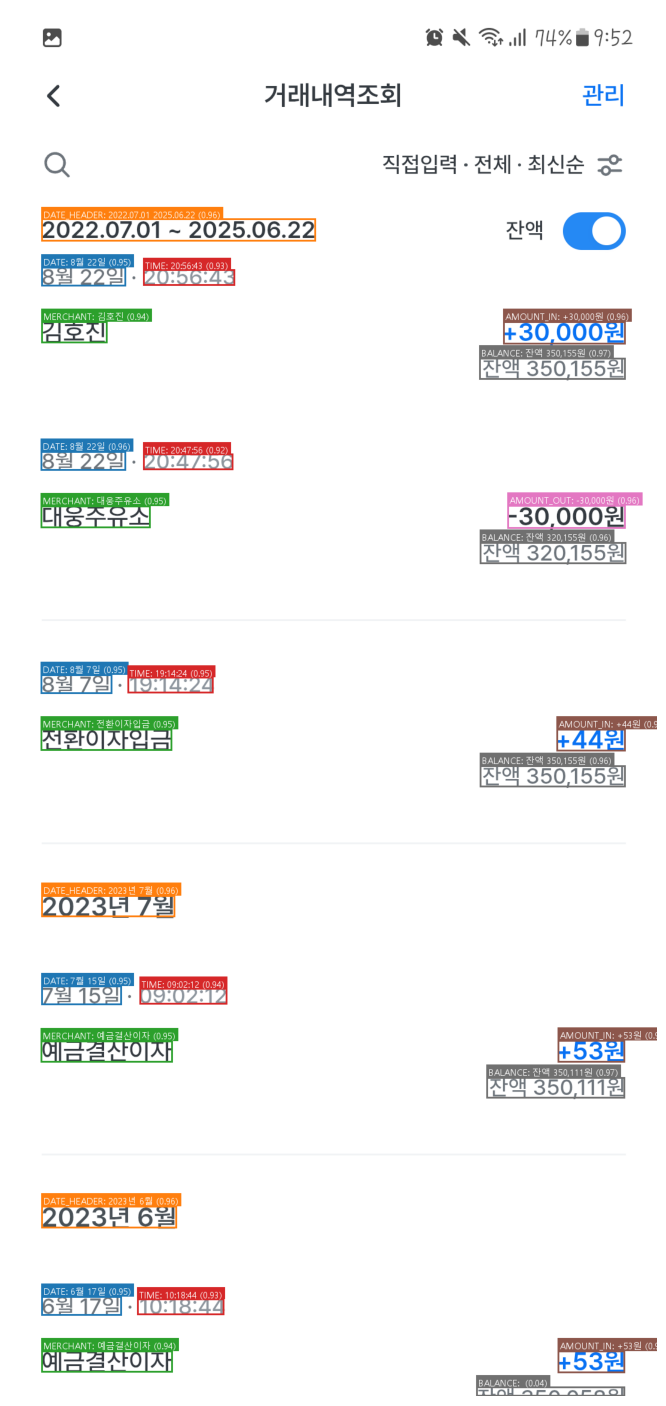

[텍스트 요약]
- AMOUNT_IN: +30,000원, +44원, +53원, +53원
- AMOUNT_OUT: -30,000원
- BALANCE: 잔액 350,155원, 잔액 320,155원, 잔액 350,155원, 잔액 350,111원, 
- DATE: 8월 22일, 8월 22일, 8월 7일, 7월 15일, 6월 17일
- DATE_HEADER: 2022.07.01 2025.06.22, 2023년 7월, 2023년 6월
- MERCHANT: 김호진, 대웅주유소, 전환이자입금, 예금결산이자, 예금결산이자
- TIME: 20:56:43, 20:47:56, 19:14:24, 09:02:12, 10:18:44
--------------------------------------------------

--- [2단계: OCR+결과] woori4.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_woori4.png


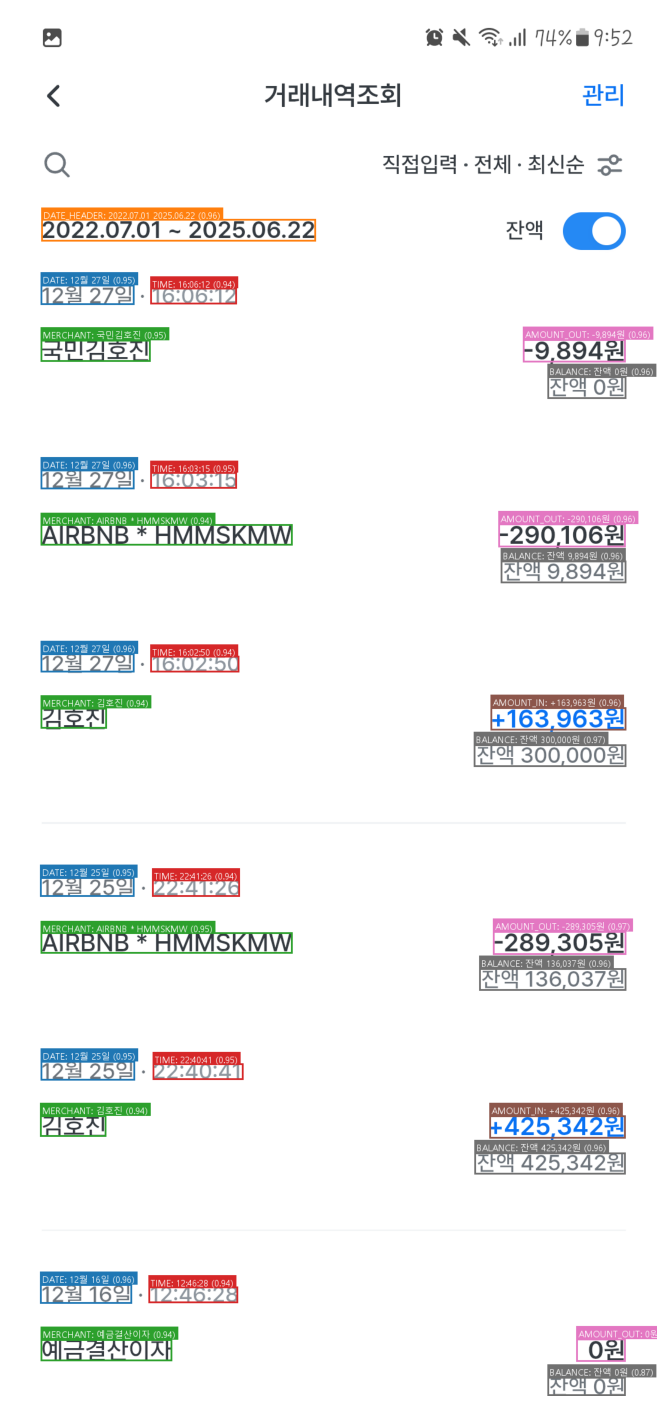

[텍스트 요약]
- AMOUNT_IN: +163,963원, +425,342원
- AMOUNT_OUT: -9,894원, -290,106원, -289,305원, 0원
- BALANCE: 잔액 0원, 잔액 9,894원, 잔액 300,000원, 잔액 136,037원, 잔액 425,342원, 잔액 0원
- DATE: 12월 27일, 12월 27일, 12월 27일, 12월 25일, 12월 25일, 12월 16일
- DATE_HEADER: 2022.07.01 2025.06.22
- MERCHANT: 국민김호진, AIRBNB * HMMSKMW, 김호진, AIRBNB * HMMSKMW, 김호진, 예금결산이자
- TIME: 16:06:12, 16:03:15, 16:02:50, 22:41:26, 22:40:41, 12:46:28
--------------------------------------------------

--- [2단계: OCR+결과] bank_statement_long.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_bank_statement_long.jpg


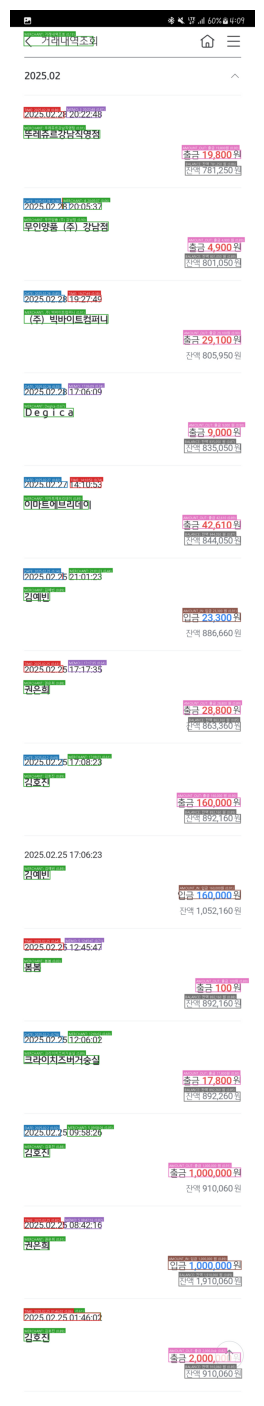

[텍스트 요약]
- AMOUNT_IN: 입금 23,300 원, 입금 160,000원, 입금 1,000,000 원
- AMOUNT_OUT: 출금 19,800원, 출금 4,900 원, 출금 29,100원, 출금 9,000 원, 출금 42,610, 출금 28,800 원, 출금 160,000 원, 출금 100원, 출금 17,800원, 출금 1,000,000 원, 출금 2,000.0ok
- BALANCE: 잔액 781,250 원, 잔액 801,050 원, 잔액 835,050 원, 잔액 844,050 원, 잔액 863,360 원, 잔액 892,160 원, 잔액 892,160 원, 잔액 892,260 원, 잔액 1,910,060 원, 잔액 910,060 원
- DATE: 2025.02.28, 2025.02.28, 2025.02.28, 2025.02.27, 2025.02.25, 2025.02.2, 2025.02.2:, 2025.02.2
- MEMO: 3 20:22:48, 17:06:09, | 17:17:35, 5 12:45:47, 5 08:42:16
- MERCHANT: 거래내역조호, 뚜레쥬르강남직영점, :8 20:05:37, 무인양품 (주) 강남점, .주) 빅바이트컴퍼니, Degica, 이마트에브리데이, 21:01:23, 김예빈, 권은희, 17:08:23, 김호진, 김예빈, 봄봄, 12:06:02, 크라이치즈버거숭실, 5 09:58:26, 김호진, 권은희, 2025.02.25 01:46:02, 김호진
- TIME: 2025.02.28, 28 20:05:37, 19:27:49, 14:10:53, 2025.02.2:, 2025.02.25, 2025.02.25, 2025.02.25, 2025.02.25 01:46:02
--------------------------------------------------

--- [2단계: OCR+결과] kabang1.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_kaba

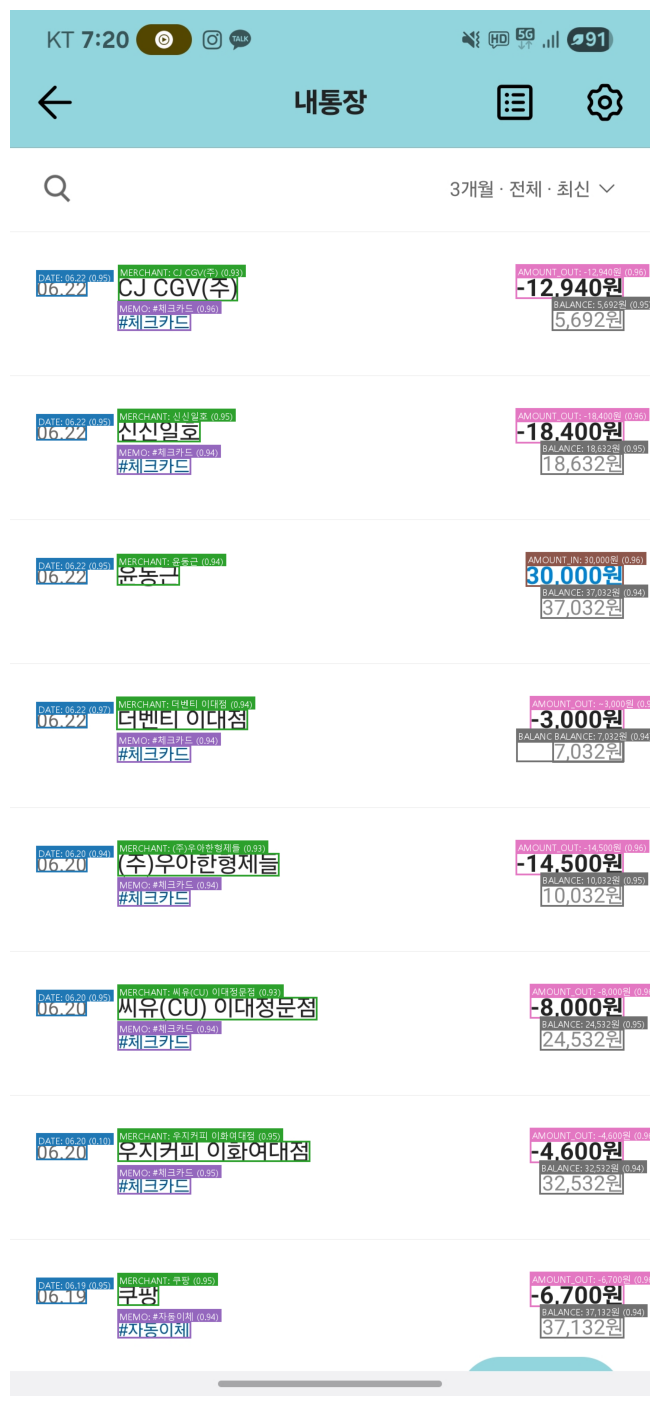

[텍스트 요약]
- AMOUNT_IN: 30,000원
- AMOUNT_OUT: -12,940원, -18,400원, ~3,000원, -14,500원, -8,000원, -4,600원, -6,700원
- BALANCE: 5,692원, 18,632원, 37,032원, 7,032원, 7,032원, 10,032원, 24,532원, 32,532원, 37,132원
- DATE: 06.22, 06.22, 06.22, 06.22, 06.20, 06.20, 06.20, 06.19
- MEMO: #체크카드, #체크카드, #체크카드, #체크카드, #체크카드, #체크카드, #자동이체
- MERCHANT: CJ CGV(주), 신신일호, 윤동근, 더벤티 이대점, (주)우아한형제들, 씨유(CU) 이대정문점, 우지커피 이화여대점, 쿠팡
--------------------------------------------------

--- [2단계: OCR+결과] kabang2.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_kabang2.jpg


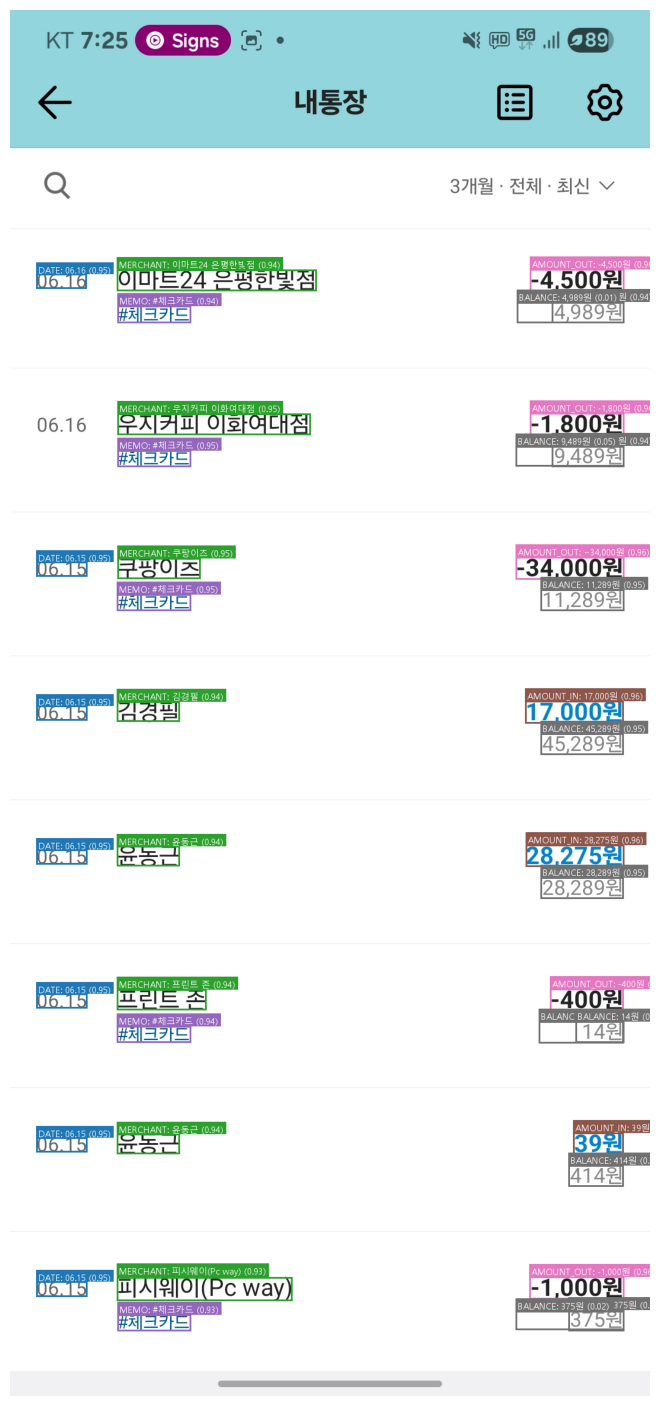

[텍스트 요약]
- AMOUNT_IN: 17,000원, 28,275원, 39원
- AMOUNT_OUT: -4,500원, -1,800원, ~34,000원, -400원, -1,000원
- BALANCE: 4,989원, 4,989원, 9,489원, 9,489원, 11,289원, 45,289원, 28,289원, 14원, 14원, 414원, 375원, 375원
- DATE: 06.16, 06.15, 06.15, 06.15, 06.15, 06.15, 06.15
- MEMO: #체크카드, #체크카드, #체크카드, #체크카드, #체크카드
- MERCHANT: 이마트24 은평한빛점, 우지커피 이화여대점, 쿠팡이츠, 김경필, 윤동근, 프린트 존, 윤동근, 피시웨이(Pc way)
--------------------------------------------------

--- [2단계: OCR+결과] kabang3.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_kabang3.jpg


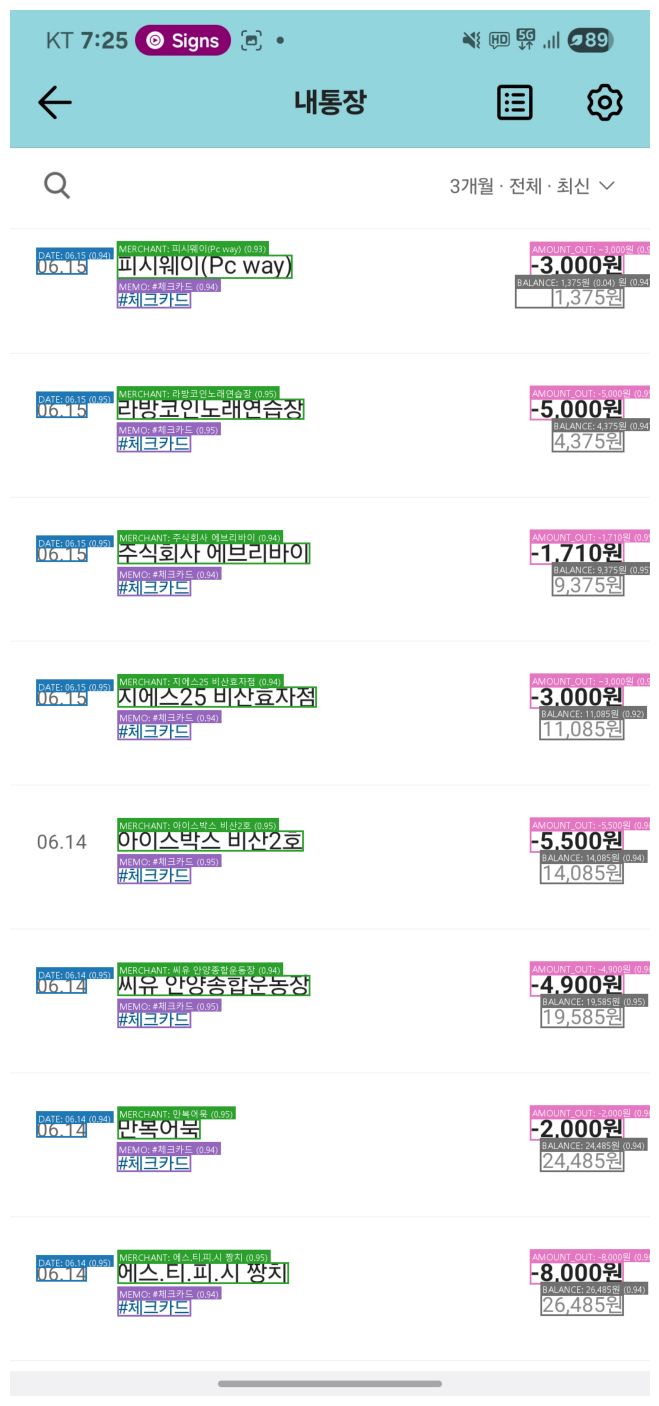

[텍스트 요약]
- AMOUNT_OUT: ~3,000원, -5,000원, -1,710원, ~3,000원, -5,500원, -4,900원, -2,000원, -8,000원
- BALANCE: 1,375원, 1,375원, 4,375원, 9,375원, 11,085원, 14,085원, 19,585원, 24,485원, 26,485원
- DATE: 06.15, 06.15, 06.15, 06.15, 06.14, 06.14, 06.14
- MEMO: #체크카드, #체크카드, #체크카드, #체크카드, #체크카드, #체크카드, #체크카드, #체크카드
- MERCHANT: 피시웨이(Pc way), 라방코인노래연습장, 주식회사 에브리바이, 지에스25 비산효자점, 아이스박스 비산2호, 씨유 안양종합운동장, 만복어묵, 에스.티.피.시 짱치
--------------------------------------------------

--- [2단계: OCR+결과] kabang4.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_kabang4.jpg


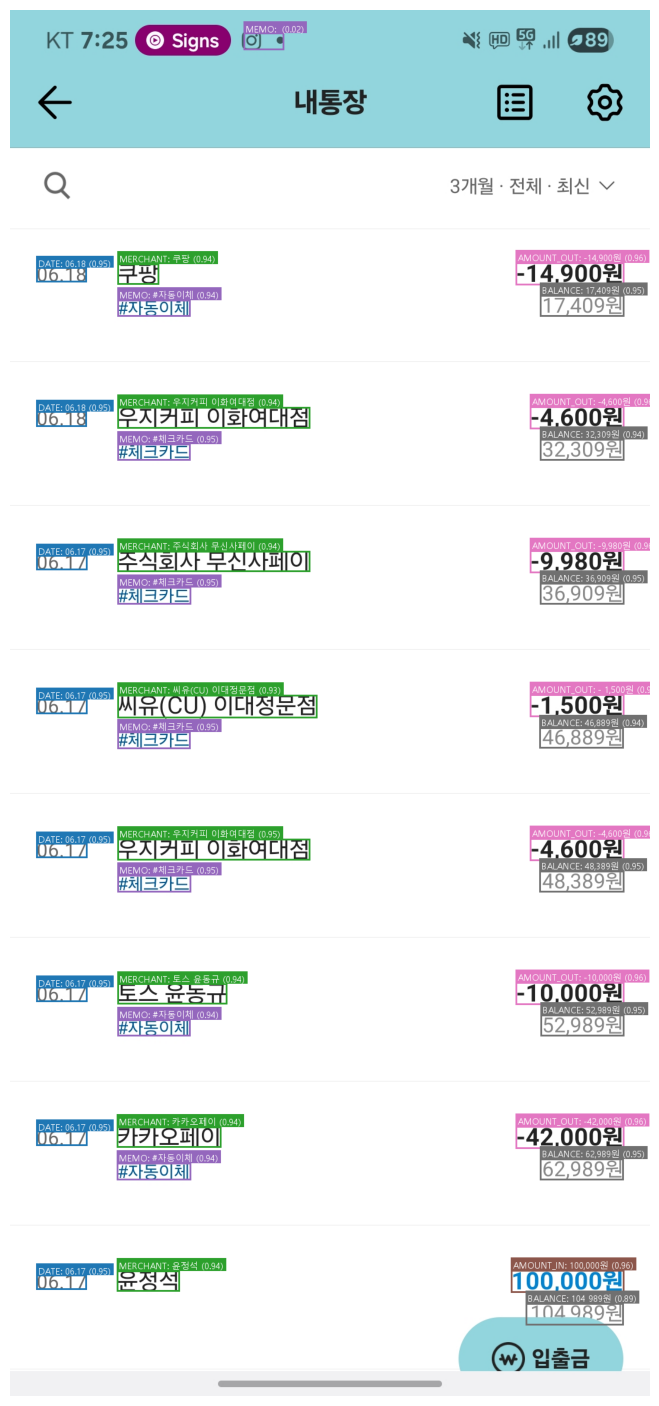

[텍스트 요약]
- AMOUNT_IN: 100,000원
- AMOUNT_OUT: -14,900원, -4,600원, -9,980원, - 1,500원, -4,600원, -10,000원, -42,000원
- BALANCE: 17,409원, 32,309원, 36,909원, 46,889원, 48,389원, 52,989원, 62,989원, 104 989원
- DATE: 06.18, 06.18, 06.17, 06.17, 06.17, 06.17, 06.17, 06.17
- MEMO: , #자동이체, #체크카드, #체크카드, #체크카드, #체크카드, #자동이체, #자동이체
- MERCHANT: 쿠팡, 우지커피 이화여대점, 주식회사 무신사페이, 씨유(CU) 이대정문점, 우지커피 이화여대점, 토스 윤동규, 카카오페이, 윤정석
--------------------------------------------------

--- [2단계: OCR+결과] shinhan2.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_shinhan2.jpg


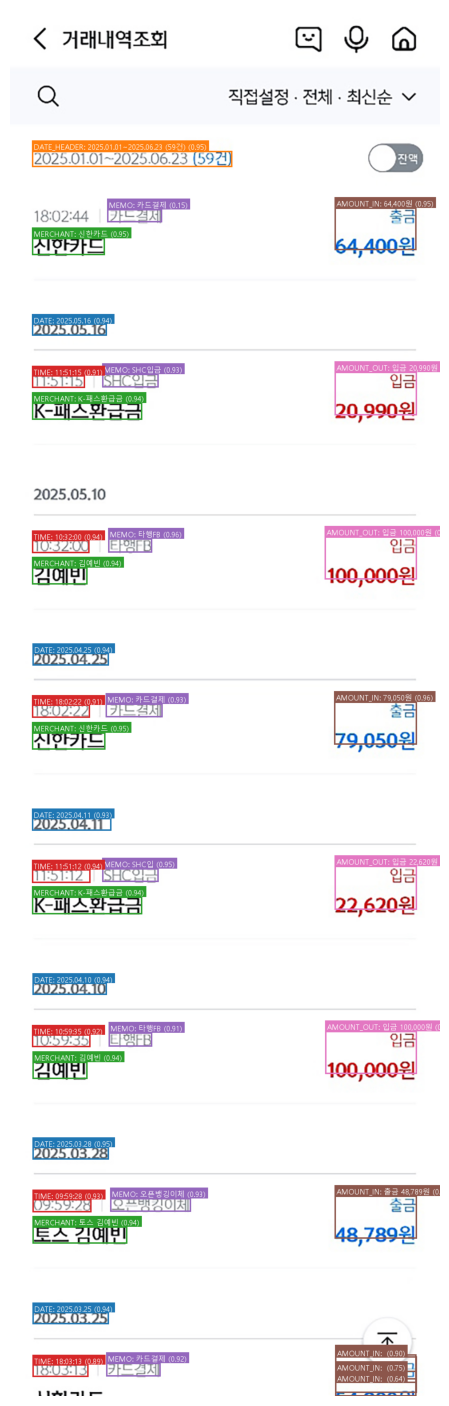

[텍스트 요약]
- AMOUNT_IN: 64,400원, 79,050원, 출금 48,789원, , , , 
- AMOUNT_OUT: 입금 20,990원, 입금 100,000원, 입금 22,620원, 입금 100,000원
- DATE: 2025.05.16, 2025.04.25, 2025.04.11, 2025.04.10, 2025.03.28, 2025.03.25
- DATE_HEADER: 2025.01.01~2025.06.23 (59건)
- MEMO: 카드결제, SHC입금, 타행FB, 카드결제, SHC입, 타행FB, 오픈뱅깅이체, 카드결제
- MERCHANT: 신한카드, K-패스환급금, 김예빈, 신한카드, K-패스환급금, 김예빈, 토스 김예빈
- TIME: 11:51:15, 10:32:00, 18:02:22, 11:51:12, 10:59:35, 09:59:28, 18:03:13
--------------------------------------------------

--- [2단계: OCR+결과] shinhan3.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_shinhan3.jpg


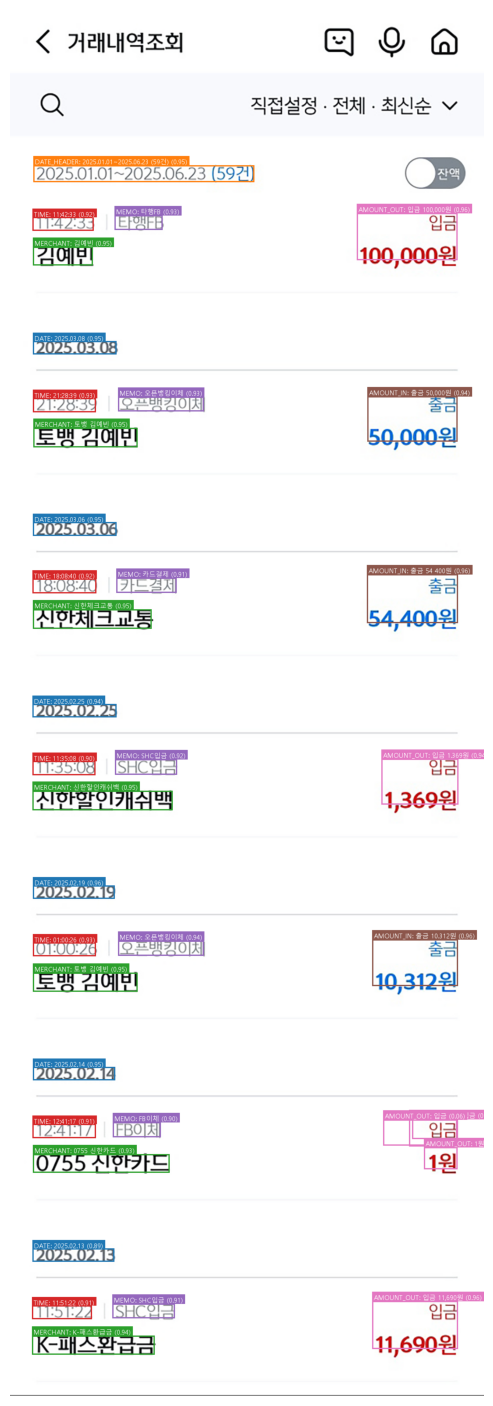

[텍스트 요약]
- AMOUNT_IN: 출금 50,000원, 출금 54 400원, 출금 10.312원
- AMOUNT_OUT: 입금 100,000원, 입금 1.369원, 입금, 입금, 입금, 1원, 입금 11,690원
- DATE: 2025.03.08, 2025.03.06, 2025.02.25, 2025.02.19, 2025.02.14, 2025.02.13
- DATE_HEADER: 2025.01.01~2025.06.23 (59건)
- MEMO: 타행FB, 오픈뱅킹이체, 카드결제, SHC입금, 오픈뱅킹이체, FB이체, SHC입금
- MERCHANT: 김예빈, 토뱅 김예빈, 신한체크교통, 신한할인캐쉬백, 토뱅 김예빈, 0755 신한카드, K-패스환급금
- TIME: 11:42:33, 21:28:39, 18:08:40, 11:35:08, 01:00:26, 12:41:17, 11:51:22
--------------------------------------------------

--- [2단계: OCR+결과] shinhan4.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_shinhan4.jpg


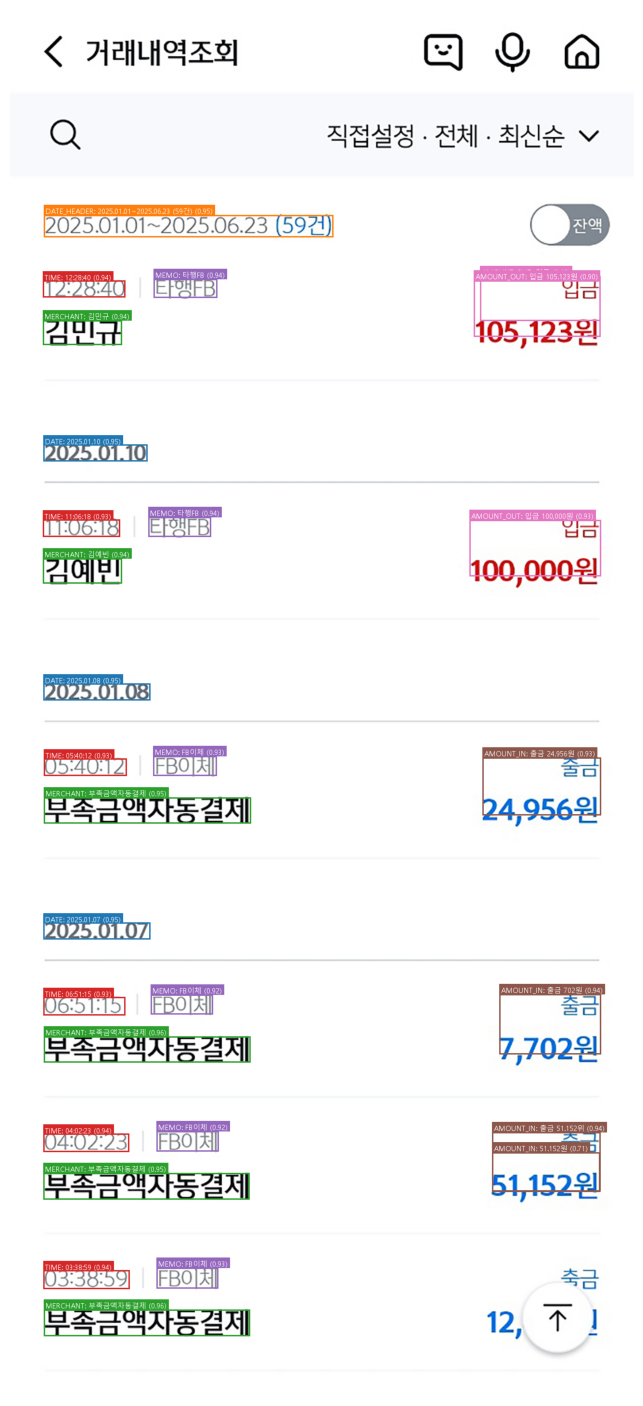

[텍스트 요약]
- AMOUNT_IN: 출금 24.956원, 출금 702원, 출금 51.152위, 51.152원
- AMOUNT_OUT: 입금, 입금 105.123원, 입금 100,000원
- DATE: 2025.01.10, 2025.01.08, 2025.01.07
- DATE_HEADER: 2025.01.01~2025.06.23 (59건)
- MEMO: 타행FB, 타행FB, FB이체, FB이체, FB이체, FB이체
- MERCHANT: 김민규, 김예빈, 부족금액자동결제, 부족금액자동결제, 부족금액자동결제, 부족금액자동결제
- TIME: 12:28:40, 11:06:18, 05:40:12, 06:51:15, 04:02:23, 03:38:59
--------------------------------------------------


In [5]:
# --- 2단계: OCR 적용 및 최종 결과 확인 (이미지 출력 및 파일 저장) ---
if not test_image_files:
    print(f"오류: 테스트 이미지가 없습니다. 이전 셀을 먼저 실행하세요.")
else:
    print(f"\n{'='*50}\n최종 OCR 결과 이미지를 '{OUTPUT_DIR}' 폴더에 저장하고 화면에 출력합니다.")
    for image_path in test_image_files:
        print(f"\n--- [2단계: OCR+결과] {os.path.basename(image_path)} ---")
        
        detections, image = predictor.detect_only(image_path, conf_threshold=CONF_THRESHOLD)
        if detections is None:
            continue
            
        predictions = predictor.run_ocr_on_detections(image, detections)
        result_image = predictor.draw_predictions(image.copy(), predictions)
        
        # 파일로 저장
        output_filename = "final_" + os.path.basename(image_path)
        output_path = os.path.join(OUTPUT_DIR, output_filename)
        result_image.save(output_path)
        print(f"-> 최종 결과 저장 완료: {output_path}")

        # ★★★ 변경: 노트북에 이미지 직접 출력 ★★★
        plt.figure(figsize=(10, 18))
        plt.imshow(result_image)
        plt.axis('off')
        plt.show()

        # 텍스트 요약은 계속 콘솔에 출력
        print("[텍스트 요약]")
        summary = defaultdict(list)
        for p in predictions:
            summary[p['label']].append(p['text'])
        
        for label, texts in sorted(summary.items()):
            print(f"- {label}: {', '.join(texts)}")
        print("-" * 50)